# Notes
- As a reminder; will need to have some tests with anisotropic dielectric systems as well.
- Will likely want to squash commits / cut test files (put on Git LFS or Zenodo) before merging to `main`.
- Need to run pre-commit formatting on all before merging to `doped` `develop`.

# Potential spherical averaging function comparison tests.

# QE tests

In [ ]:
from pymatgen.io.vasp import VolumetricData
from doped.analysis import DefectsParser
%matplotlib inline

Calculated Kumagai (eFNV) correction is 0.308 eV


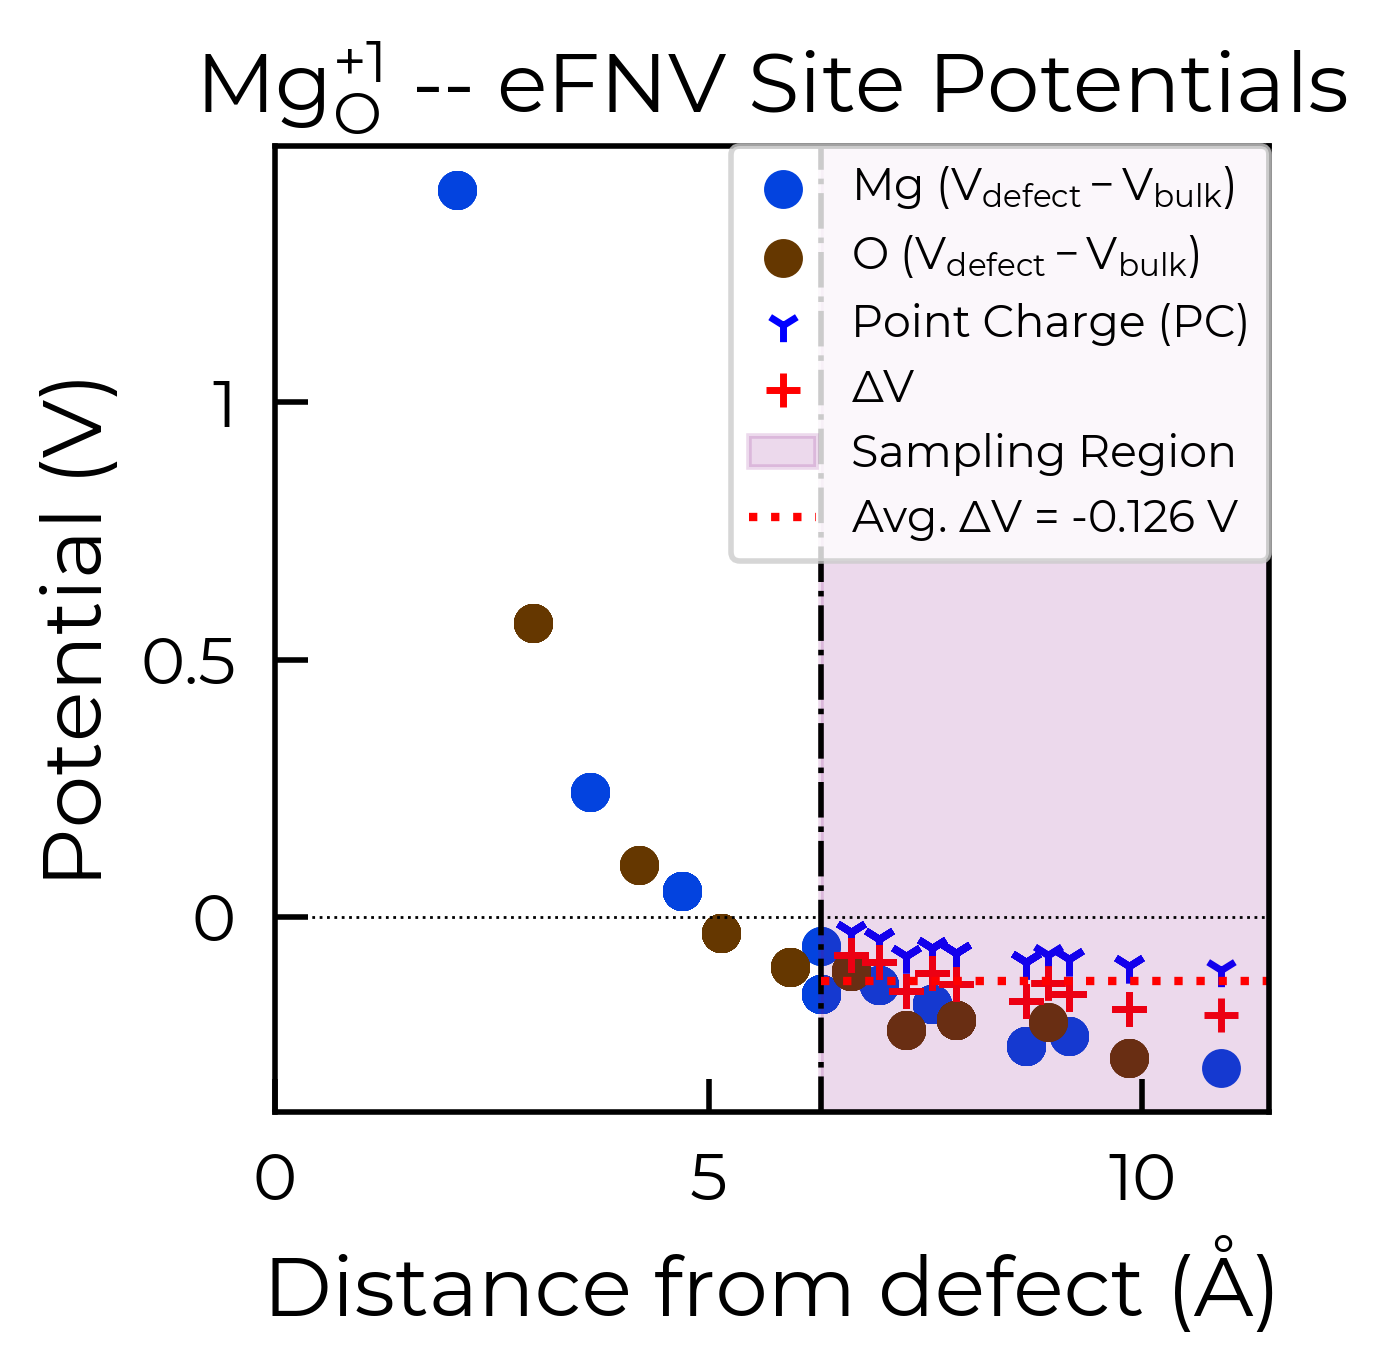

In [5]:
bulk_path = "../tests/data/espresso/MgO_qe/Defects/MgO_bulk"
dielectric = 8.8963

In [ ]:
calc_root = "../tests/data/espresso/MgO_qe/Defects"
pp_folder = "../tests/data/espresso/pp_folder"

# Defect parser automatically parses the corrections with beta - 1.5(default). (Note that beta = 1.2 gives better values)
dp = DefectsParser(code = 'espresso',
                   output_path = calc_root,
                   dielectric=8.8963,
                   beta = 1.2,
                   pp_folder = pp_folder, bulk_path = bulk_path, processes = 1)


## Unperturbed defect

Calculated Kumagai (eFNV) correction is 0.657 eV


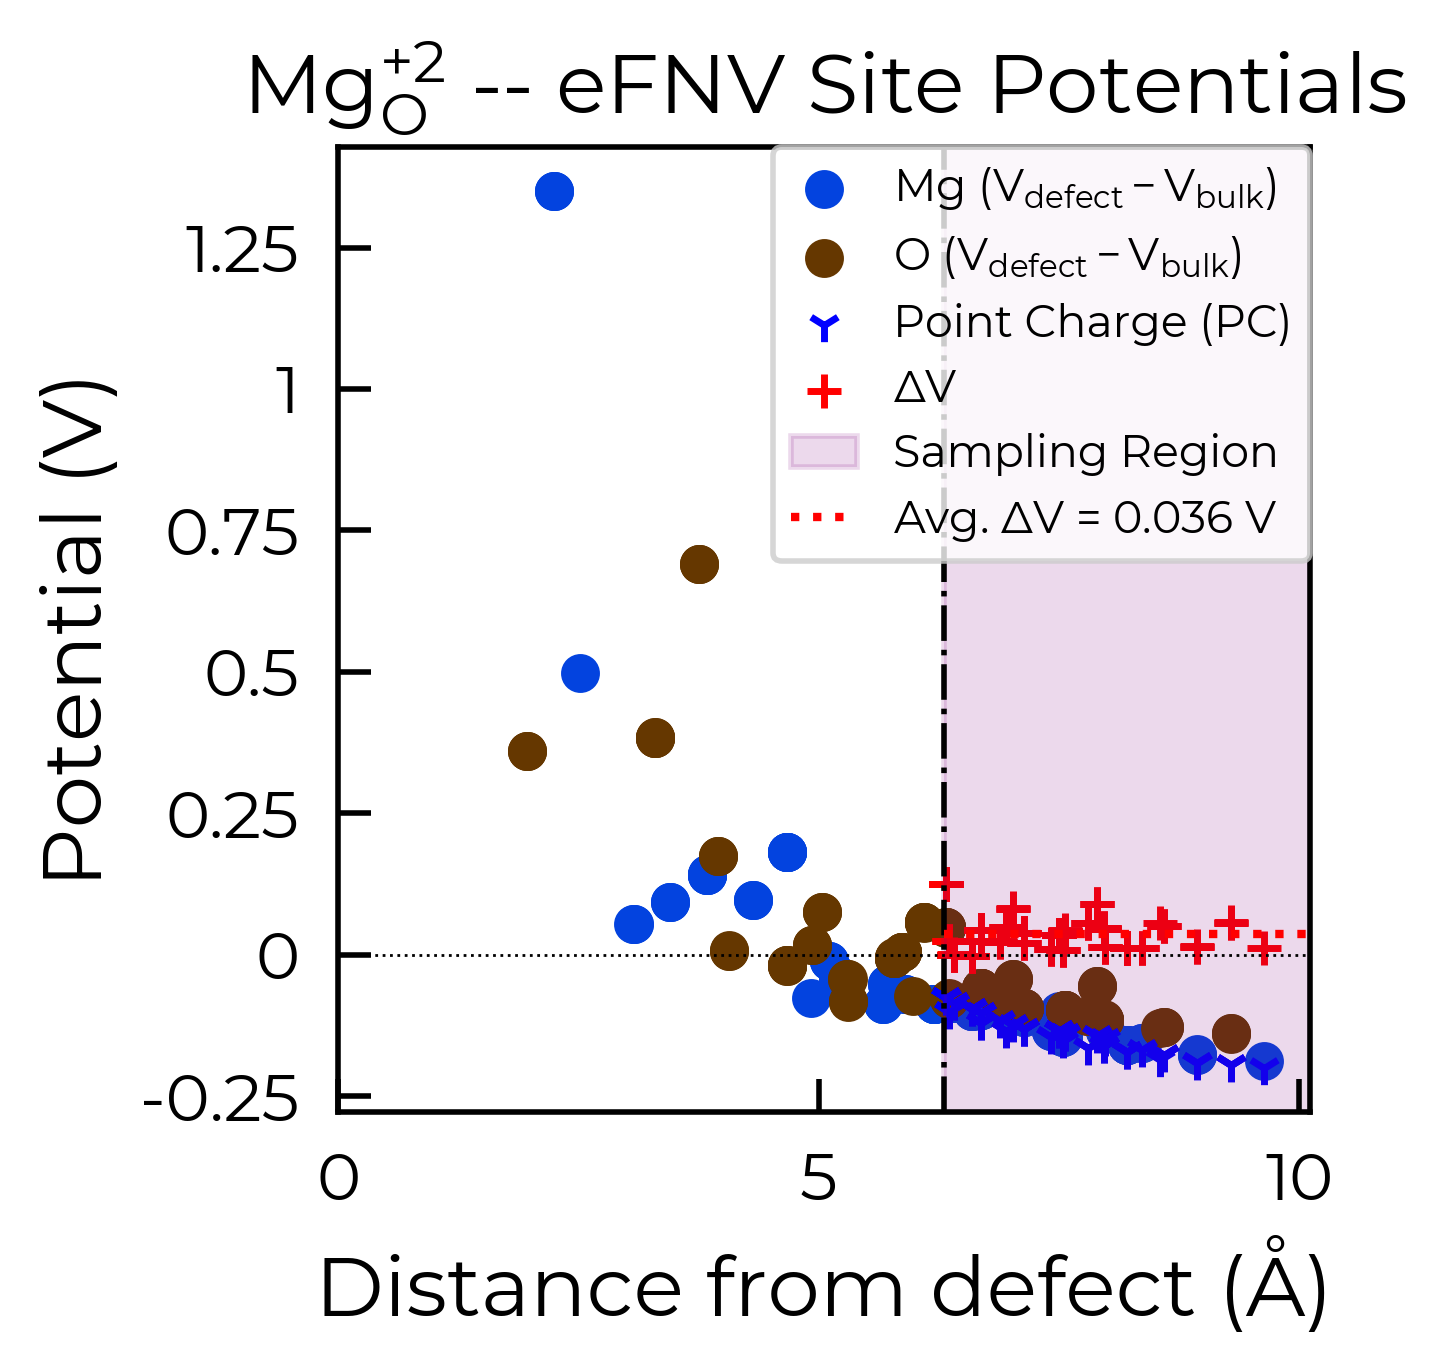

In [9]:
Mg_O_1_unperturbed_QE = dp.defect_dict["Mg_O_Unrelaxed_+1"]

Calculated Kumagai (eFNV) correction is 2.466 eV


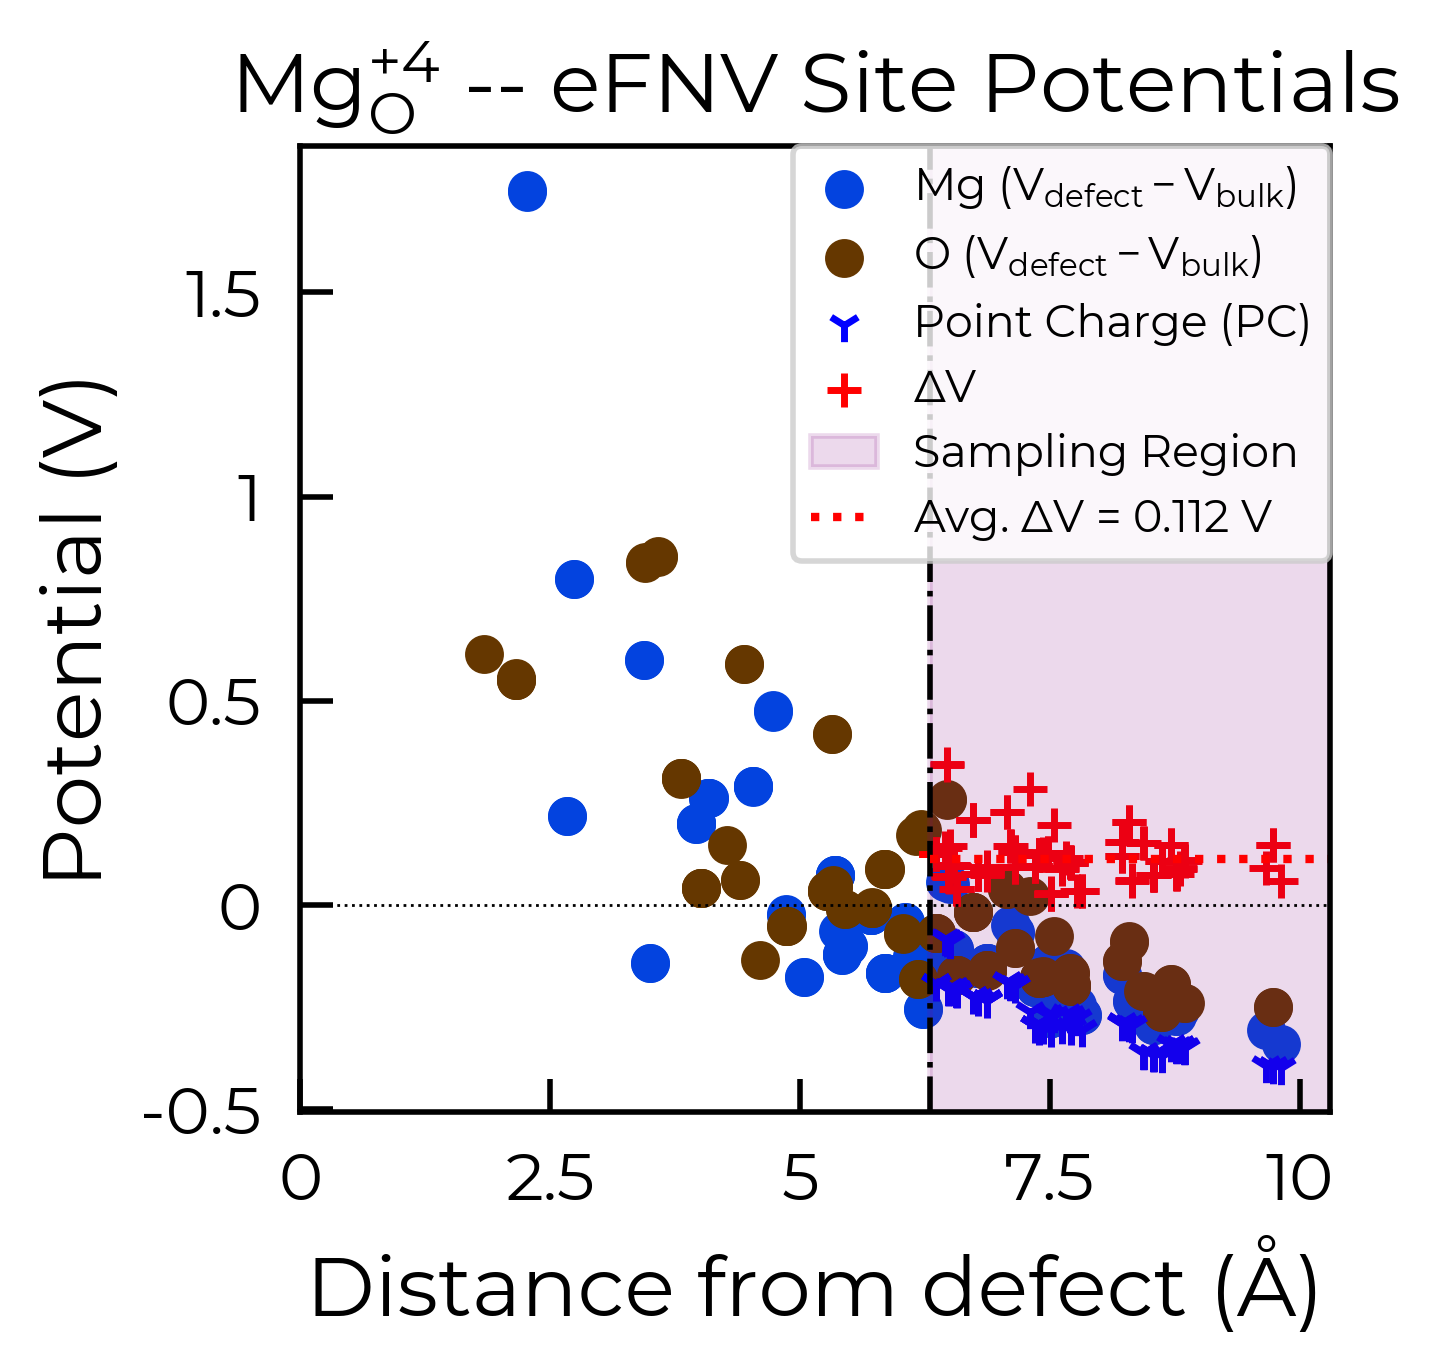

In [11]:
(
    Mg_O_1_unperturbed_eFNV_correction_QE,
    Mg_O_1_unperturbed_eFNV_plot_QE
) = Mg_O_1_unperturbed_QE.get_kumagai_correction(plot=True)

## Perturbed Defects

Note: The DefectParserEspresso reads the charge from the defect files only (in its current state), therefore accurate naming of the folder is necessary at the moment, to run the perturbed and unperturbed defects through the parser, one case(perturbed/unperturbed) needs to be calculated under the file name Mg_O_+X and then needs to be changed for the other case in Mg_O_+X form and the defect parser should be re-run. (make sure to add the appropriate cube files to load them into the calculation metadata.)

Calculated Kumagai (eFNV) correction is 0.274 eV


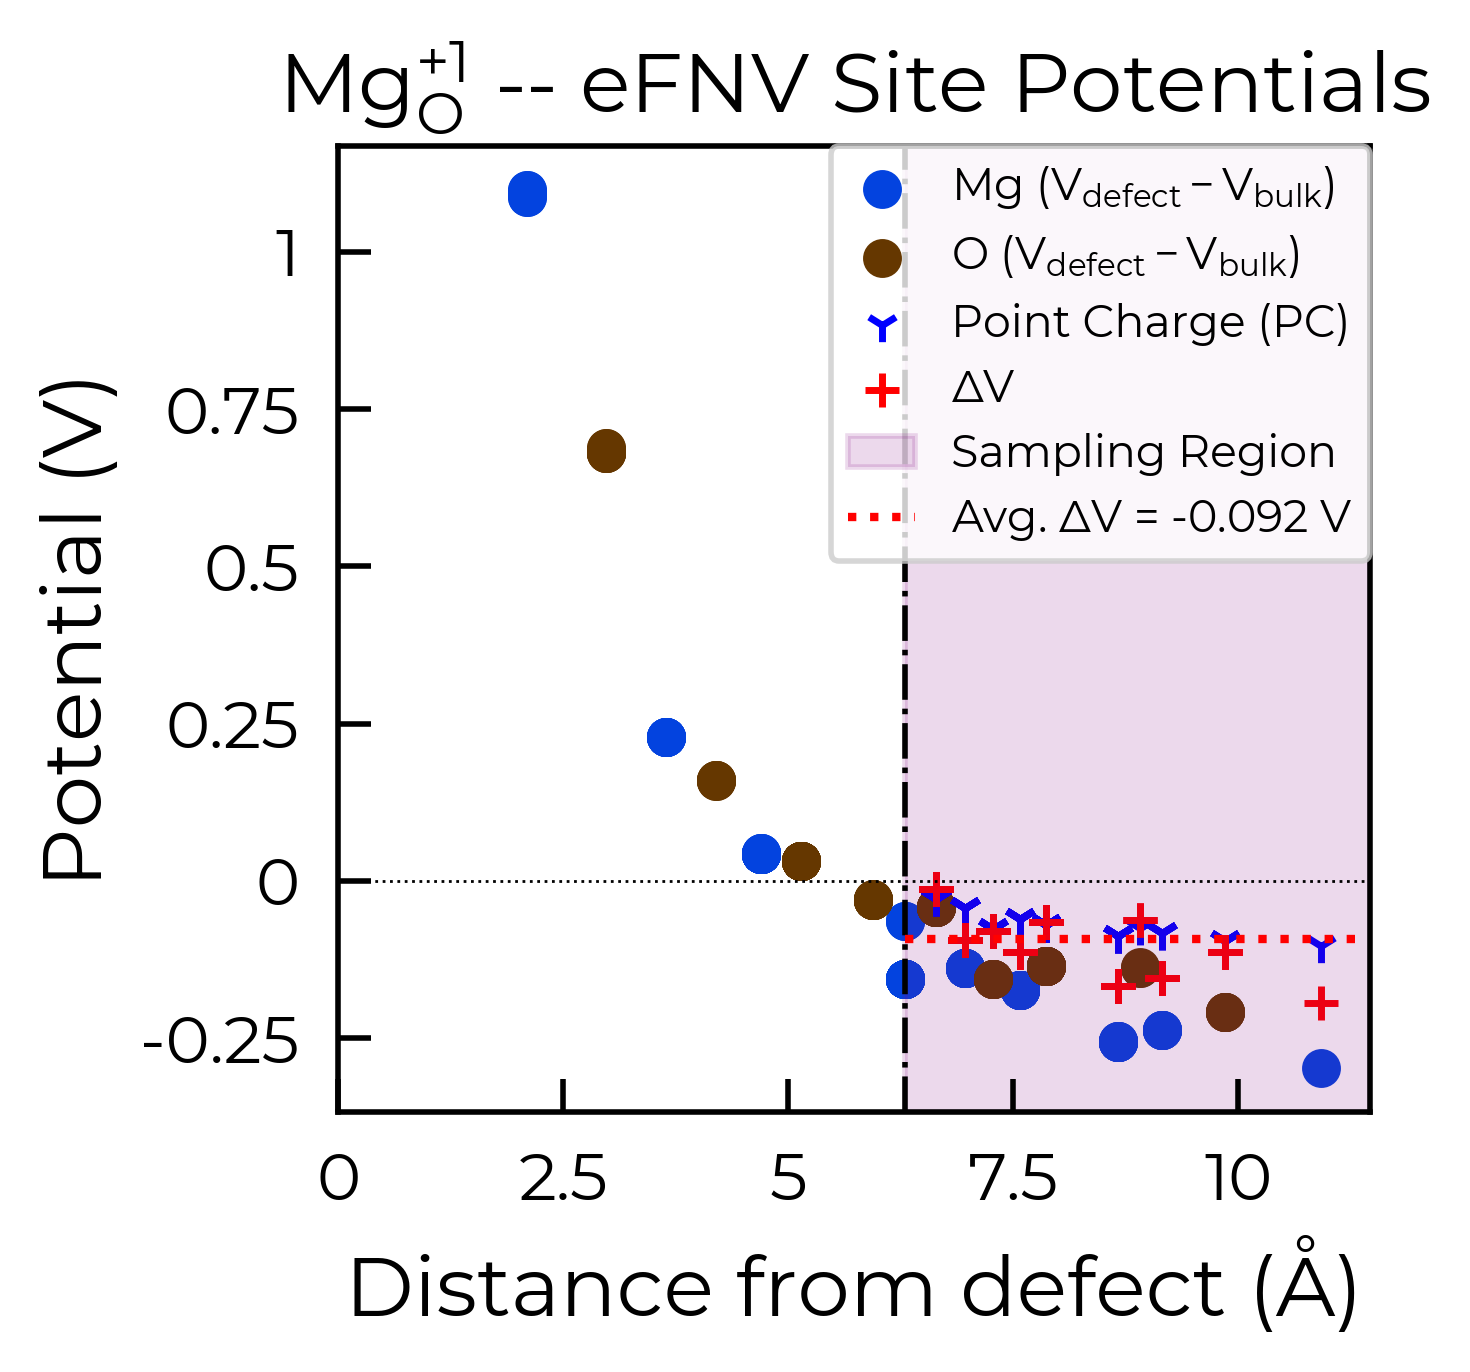

In [15]:
Mg_O_1_QE = dp.defect_dict["Mg_O_+1"]

Calculated Kumagai (eFNV) correction is 0.723 eV


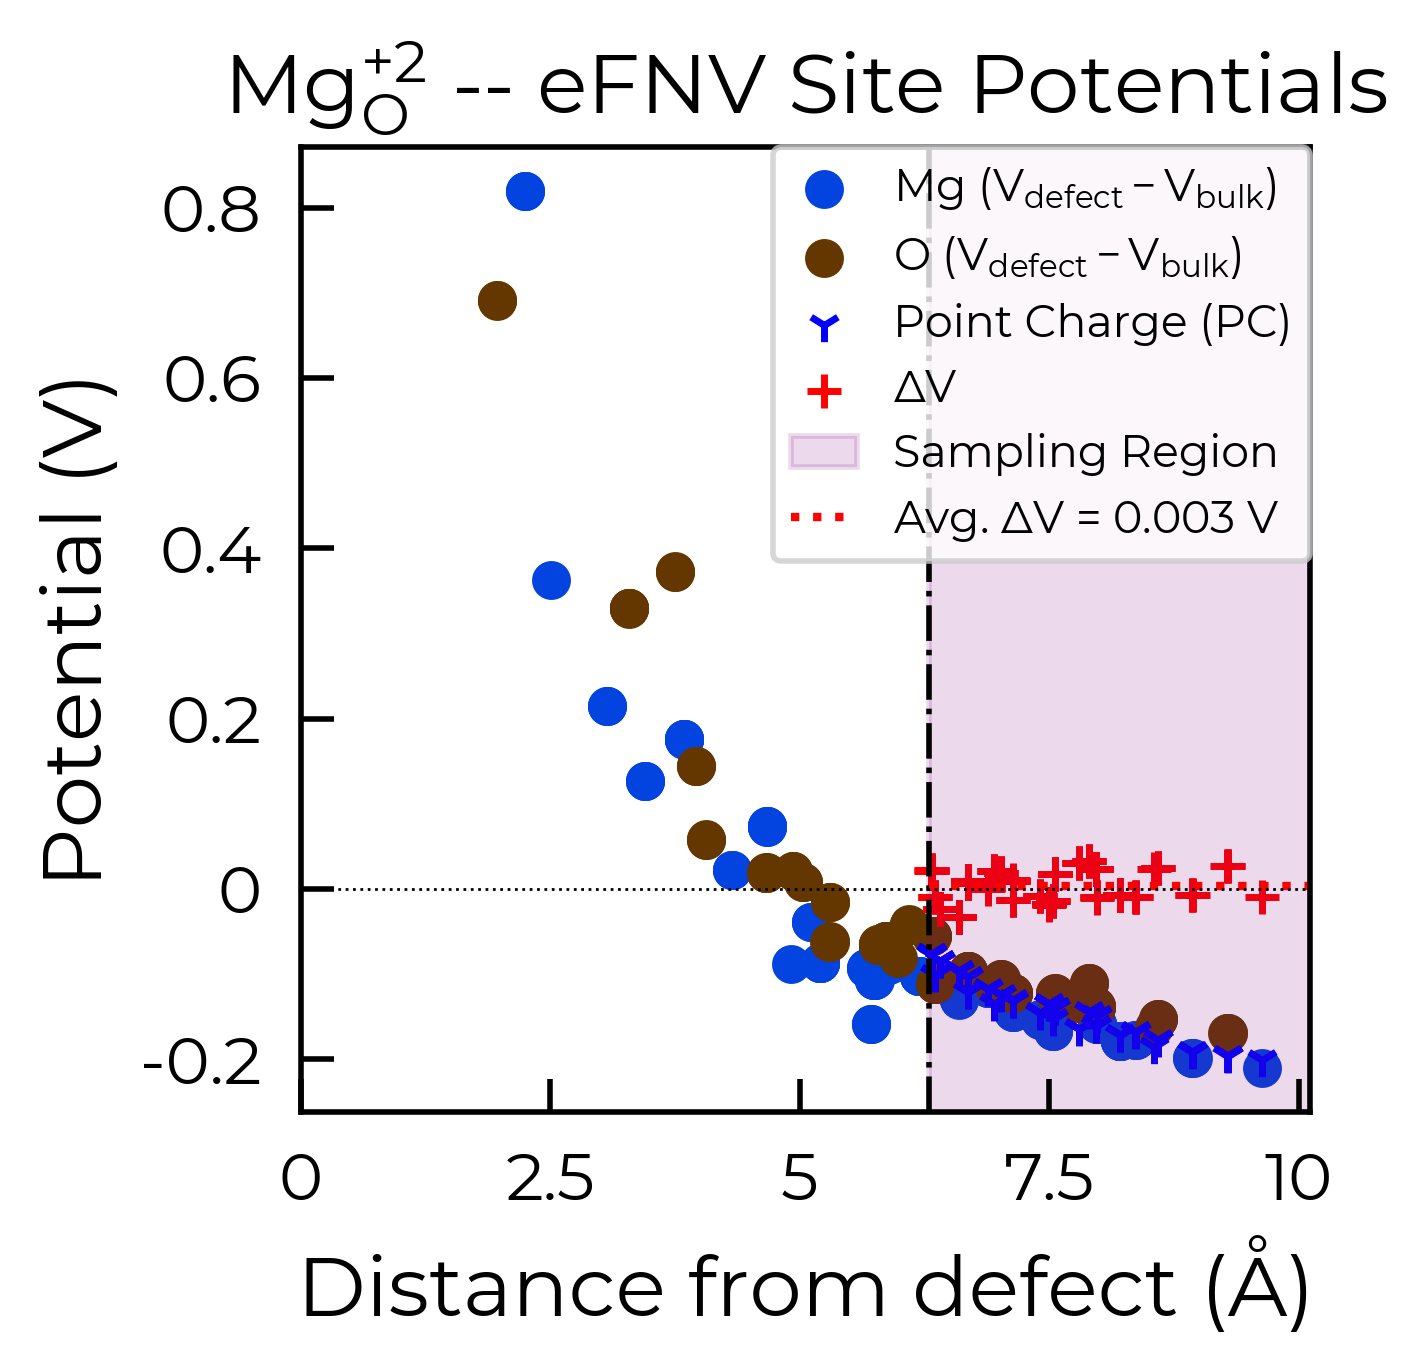

In [17]:
Mg_O_1_eFNV_correction_QE, Mg_O_1_eFNV_plot_QE = Mg_O_1_QE.get_kumagai_correction(plot=True)


Calculated Kumagai (eFNV) correction is 2.586 eV


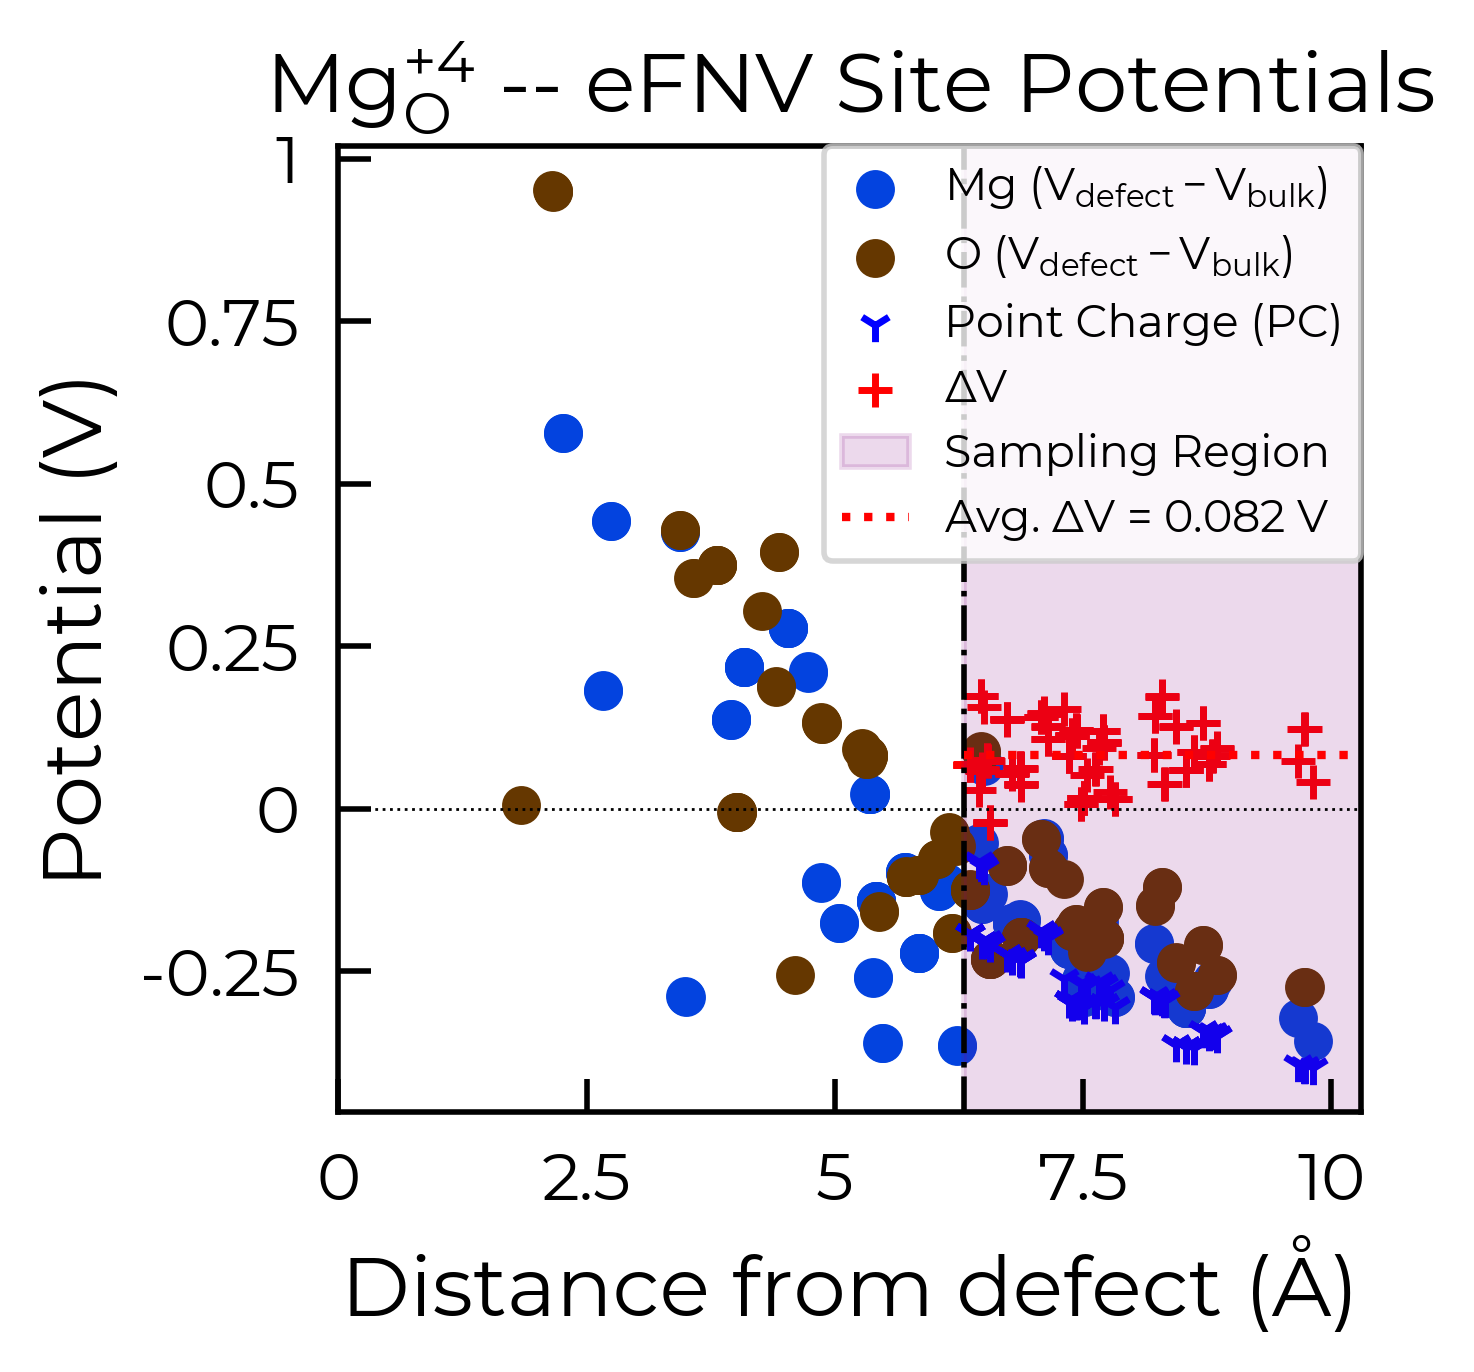

In [19]:
Mg_O_2_QE = dp.defect_dict["Mg_O_+2"]

In [ ]:
Mg_O_2_eFNV_correction_QE, Mg_O_2_eFNV_plot_QE = Mg_O_2_QE.get_kumagai_correction(plot=True)

Calculated Kumagai (eFNV) correction is 0.309 eV


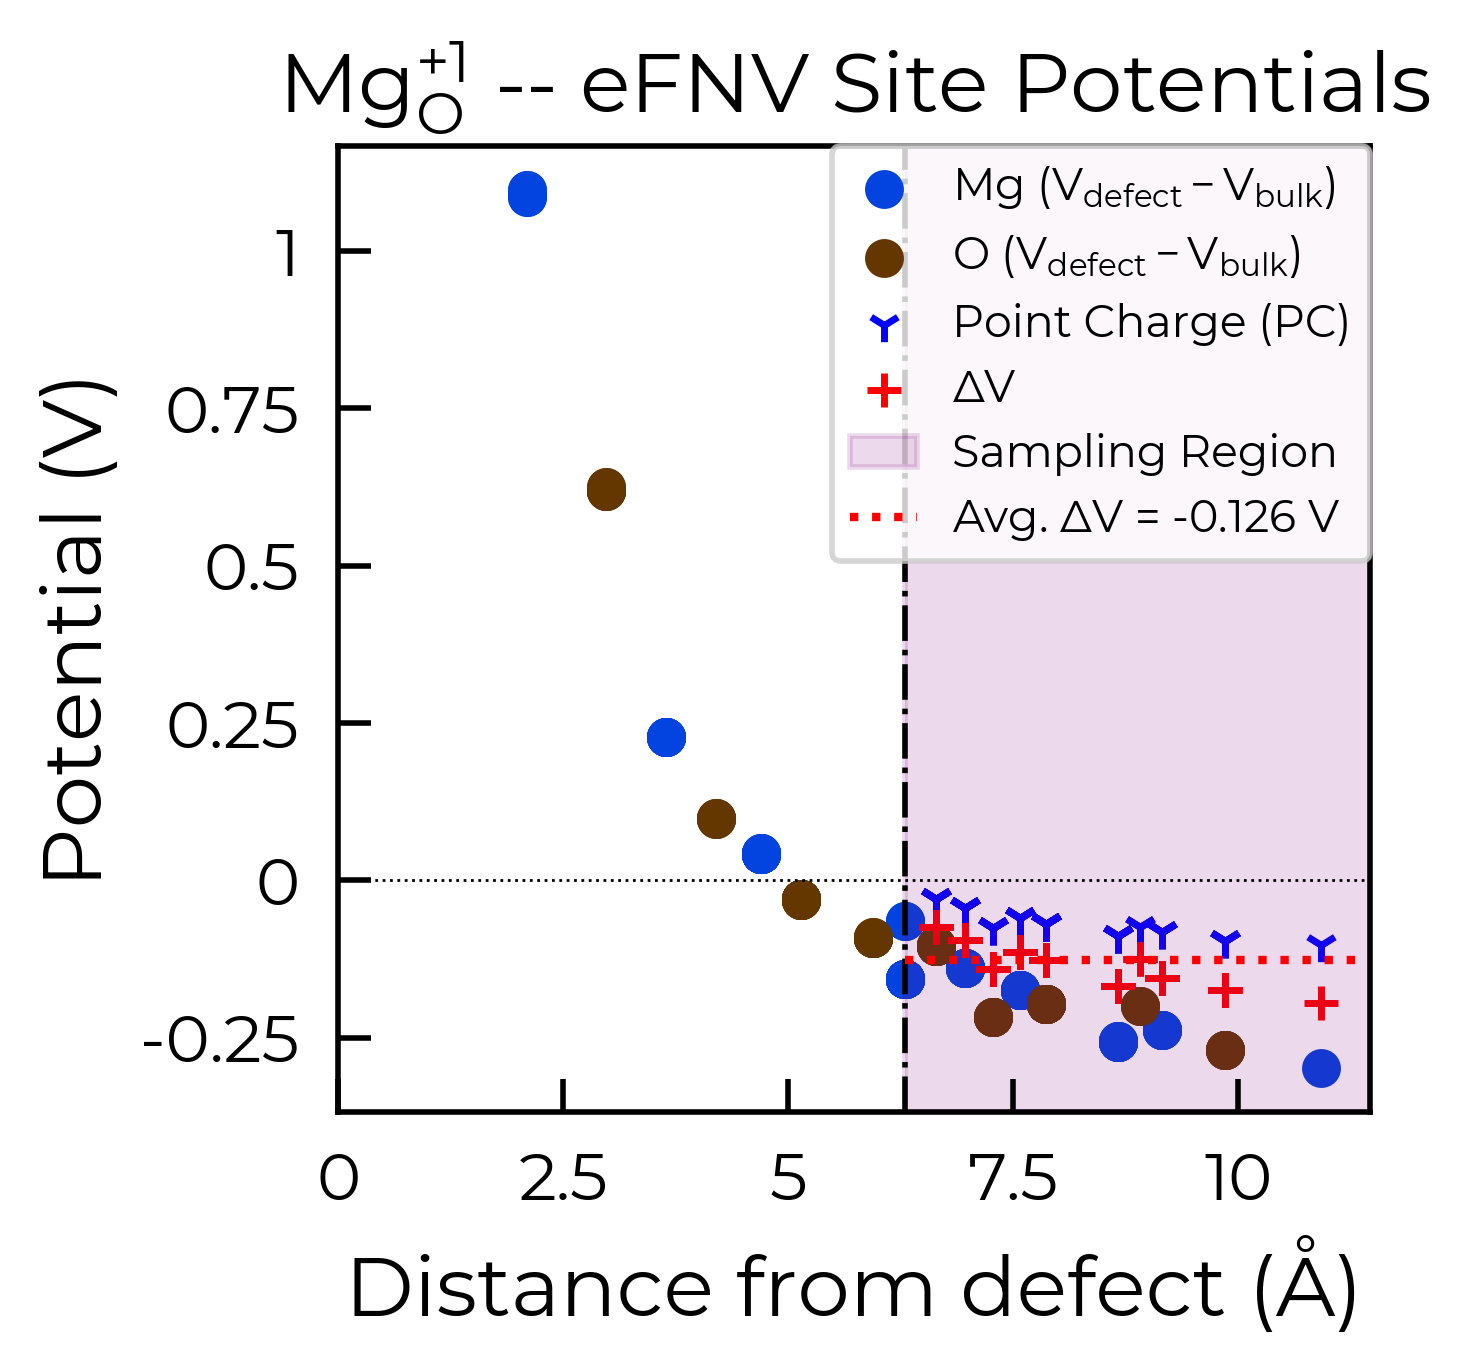

In [22]:
Mg_O_3_QE = dp.defect_dict["Mg_O_+3"]
Mg_O_3_eFNV_correction_QE, Mg_O_3_eFNV_plot_QE = Mg_O_3_QE.get_kumagai_correction(plot=True)

In [ ]:
Mg_O_4_QE = dp.defect_dict["Mg_O_+4"]
Mg_O_4_eFNV_correction_QE, Mg_O_4_eFNV_plot_QE = Mg_O_4_QE.get_kumagai_correction(plot=True)

# VASP files

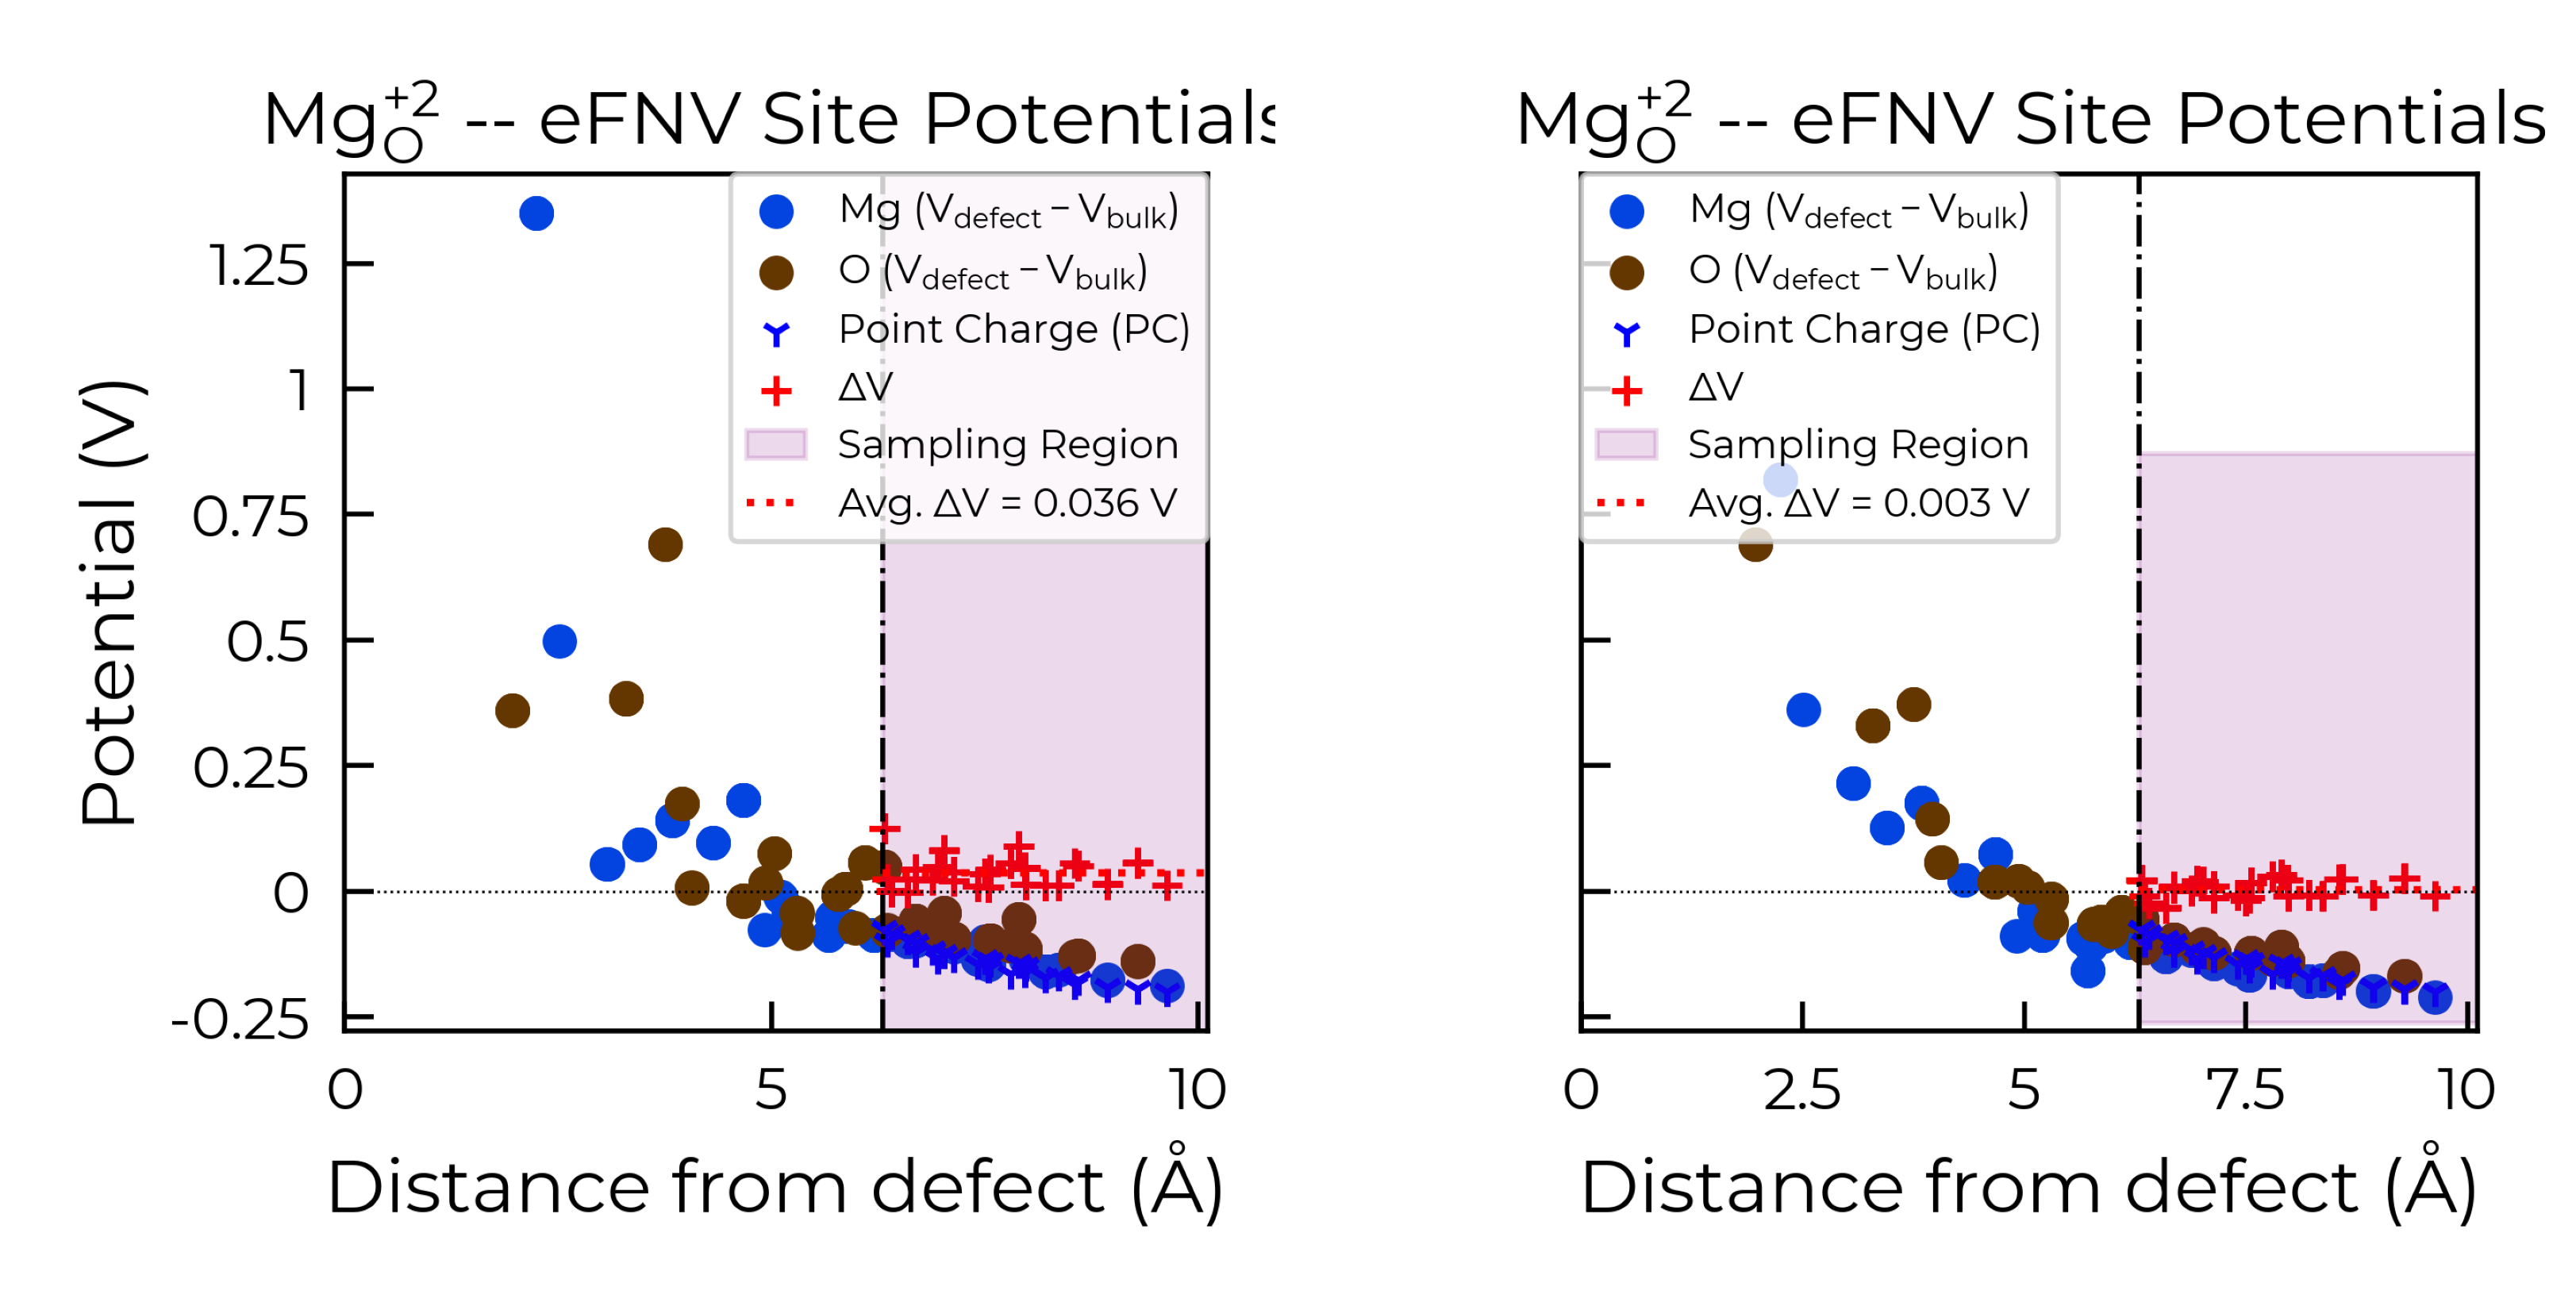

In [30]:
dp_vasp = DefectsParser(
   output_path="MgO/Defects/Pre_Calculated_Results",
   dielectric=dielectric,
   code = 'vasp'
)

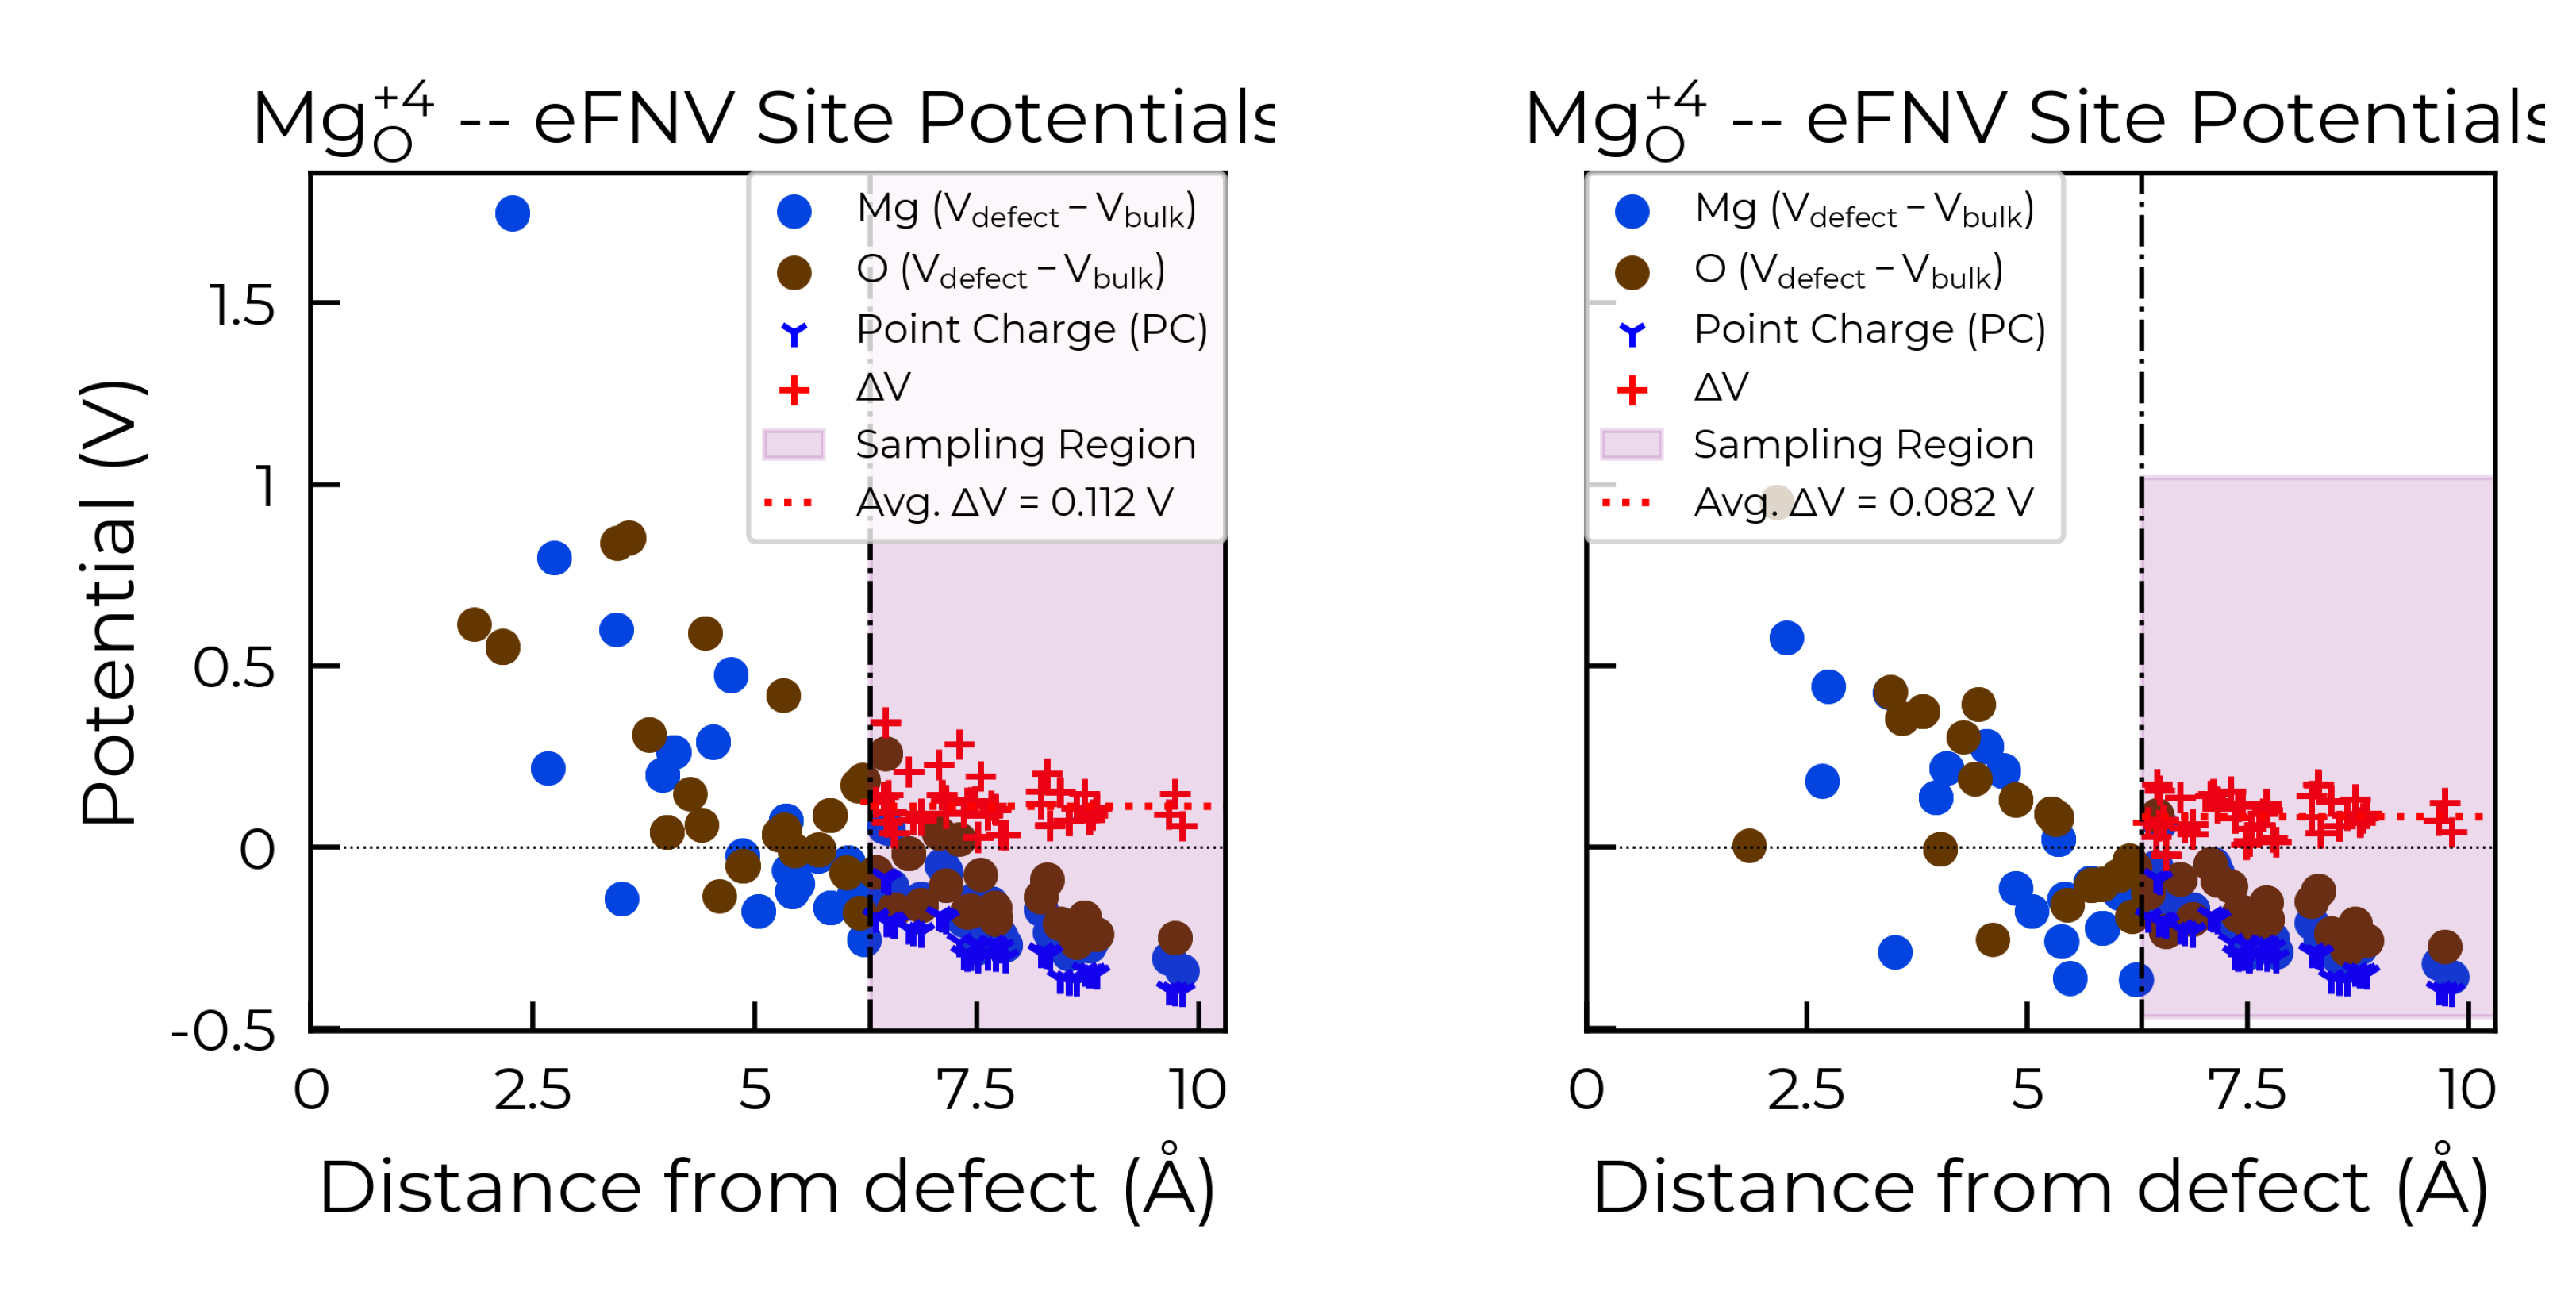

In [32]:
from doped.analysis import DefectParserVasp, DefectParserEspresso

Mg_O_1_Unperturbed = DefectParserVasp.from_paths(
    defect_path = "MgO/Defects/Mg_O_Unperturbed_+1/vasp_std",
    bulk_path = "MgO/Defects/Pre_Calculated_Results/MgO_bulk/vasp_std",
    dielectric = 8.8963,
).defect_entry

In [ ]:
vasp_defect_entry_dict = {**dp_vasp.defect_dict, "Mg_O_Unperturbed_+1": Mg_O_1_Unperturbed}

**Note: The correction value here differs slightly from the QE value, _only_ because there is a mismatch between the `ENCUT` used for the bulk and defect calculations, for the unperturbed defect.** We re-parse the unperturbed defect with a matching `ENCUT = 400` bulk calculation below, which gives a perfect match to the QE correction value.

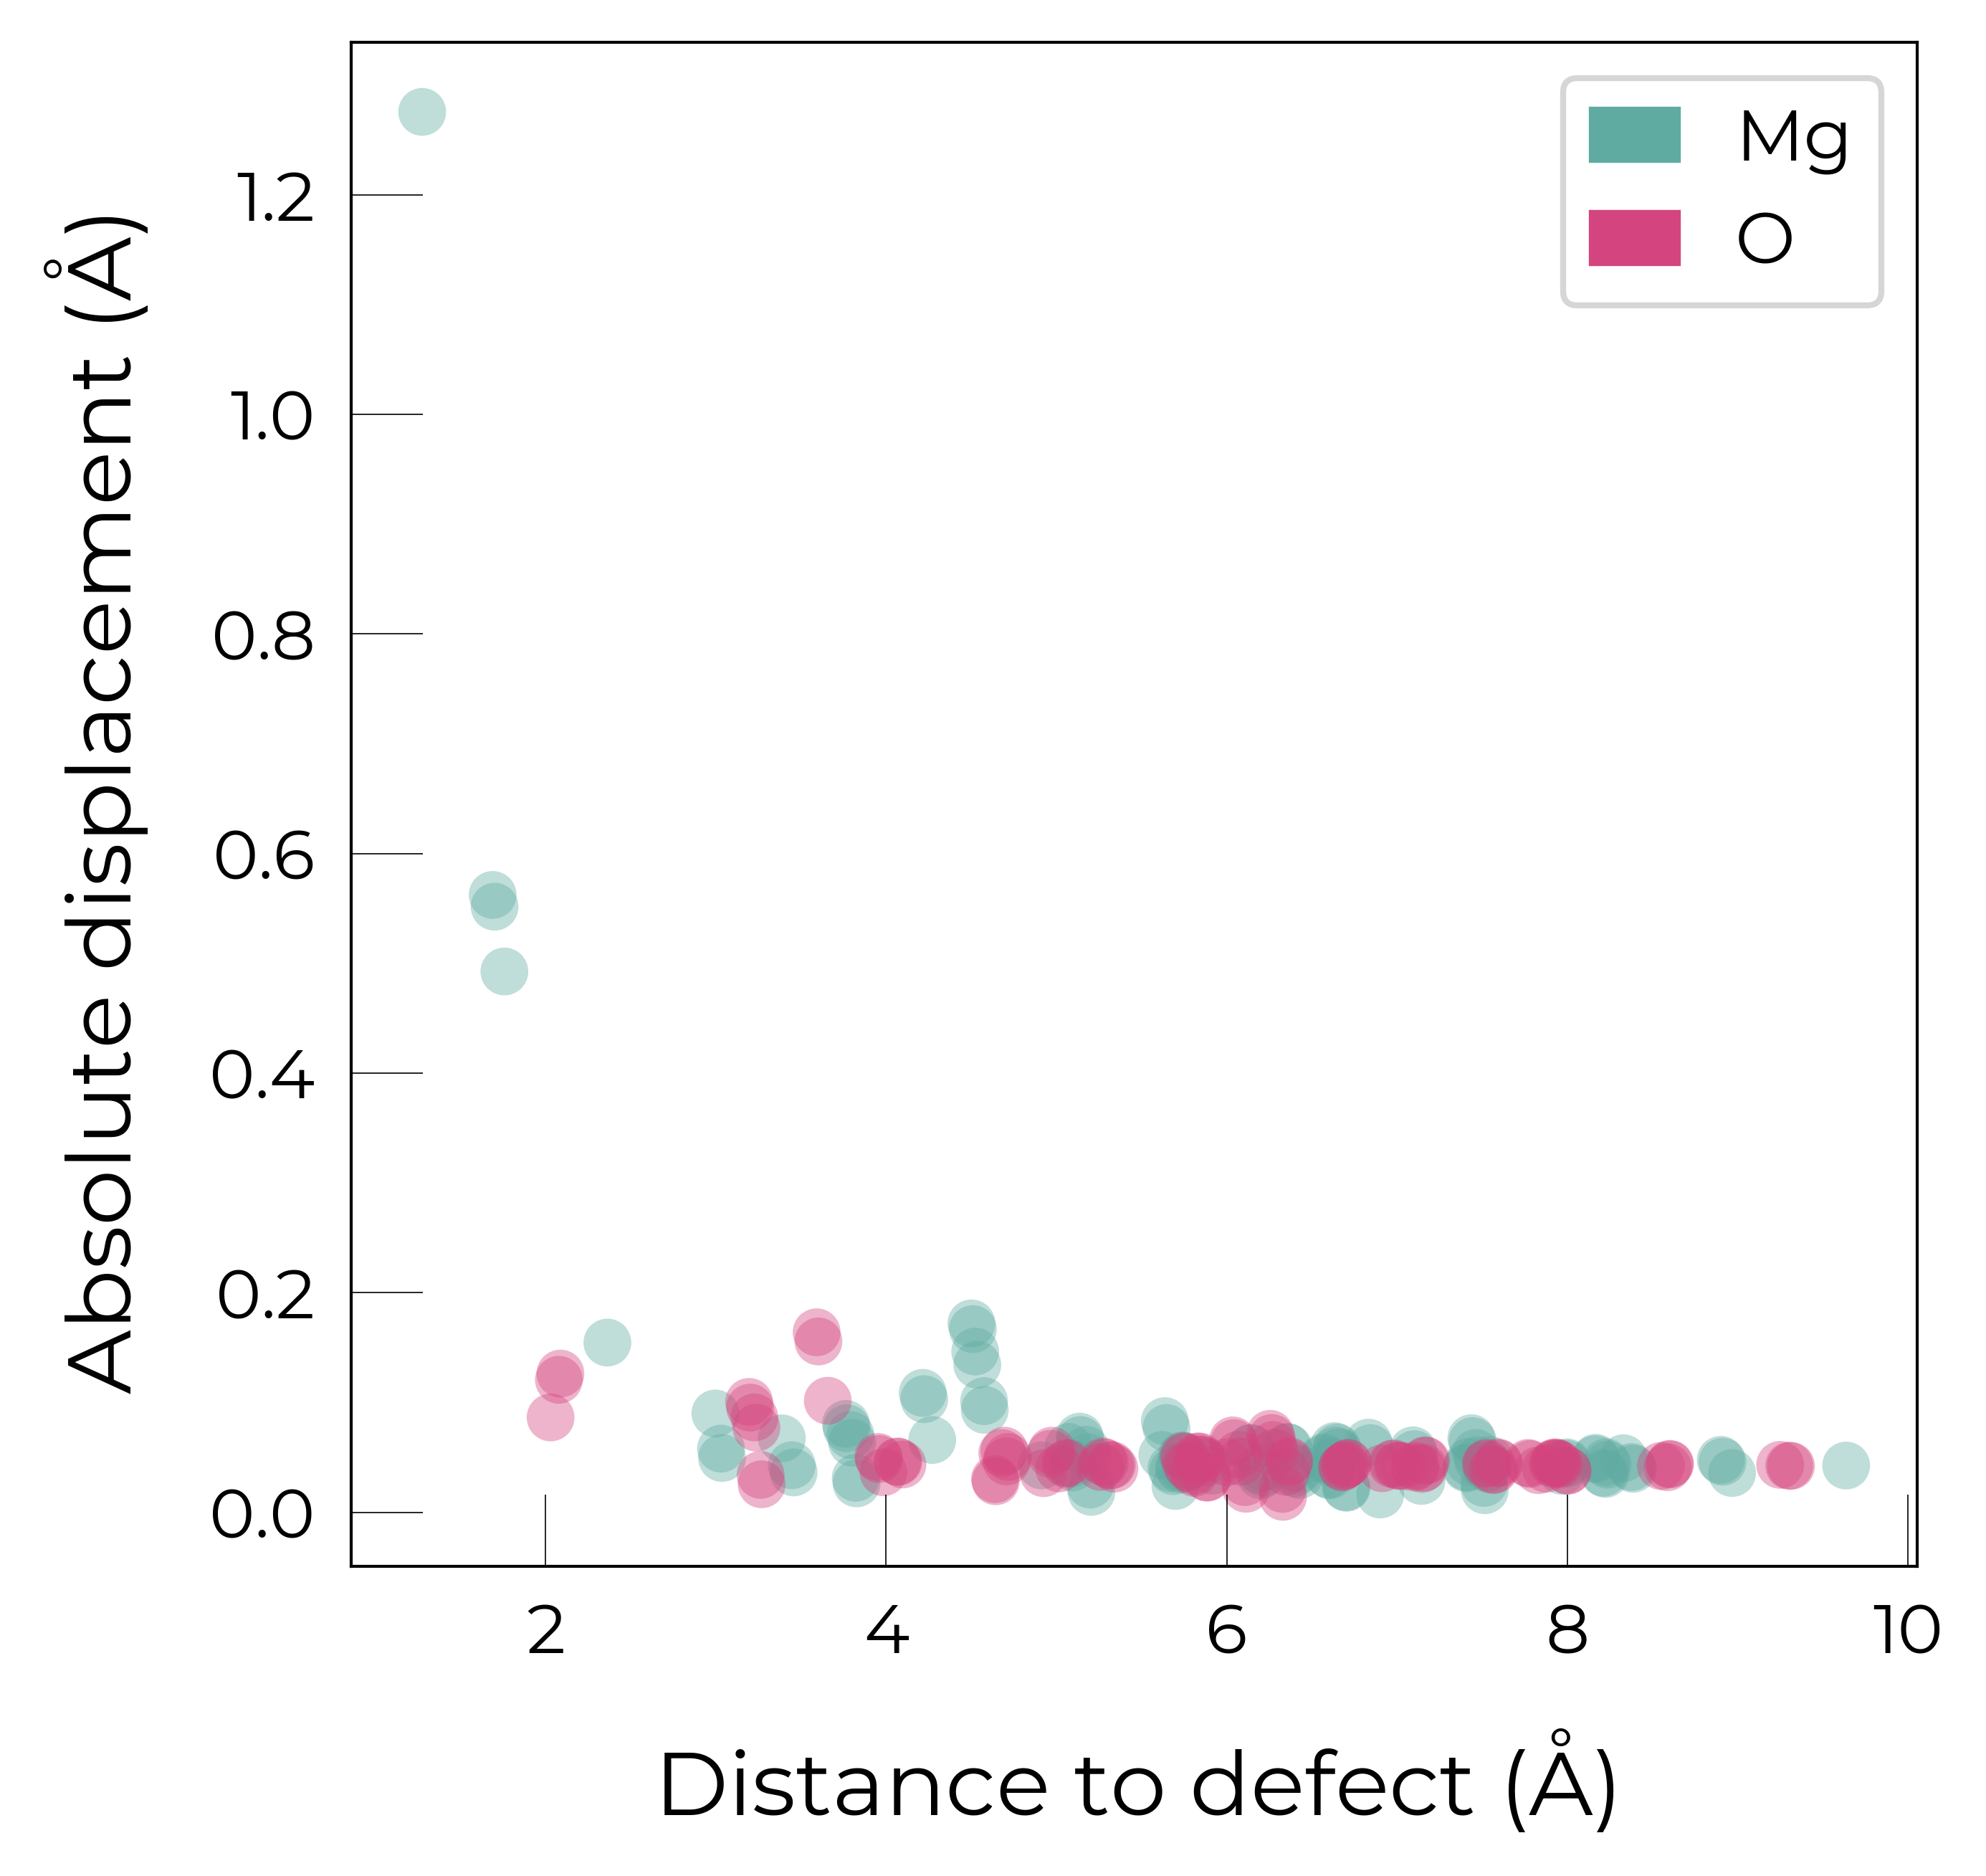

In [34]:
Mg_O_1_unperturbed_VASP = vasp_defect_entry_dict["Mg_O_Unperturbed_+1"]
(
    Mg_O_1_unperturbed_eFNV_correction_VASP,
    Mg_O_1_unperturbed_eFNV_plot_VASP
) = Mg_O_1_unperturbed_VASP.get_kumagai_correction(plot=True)

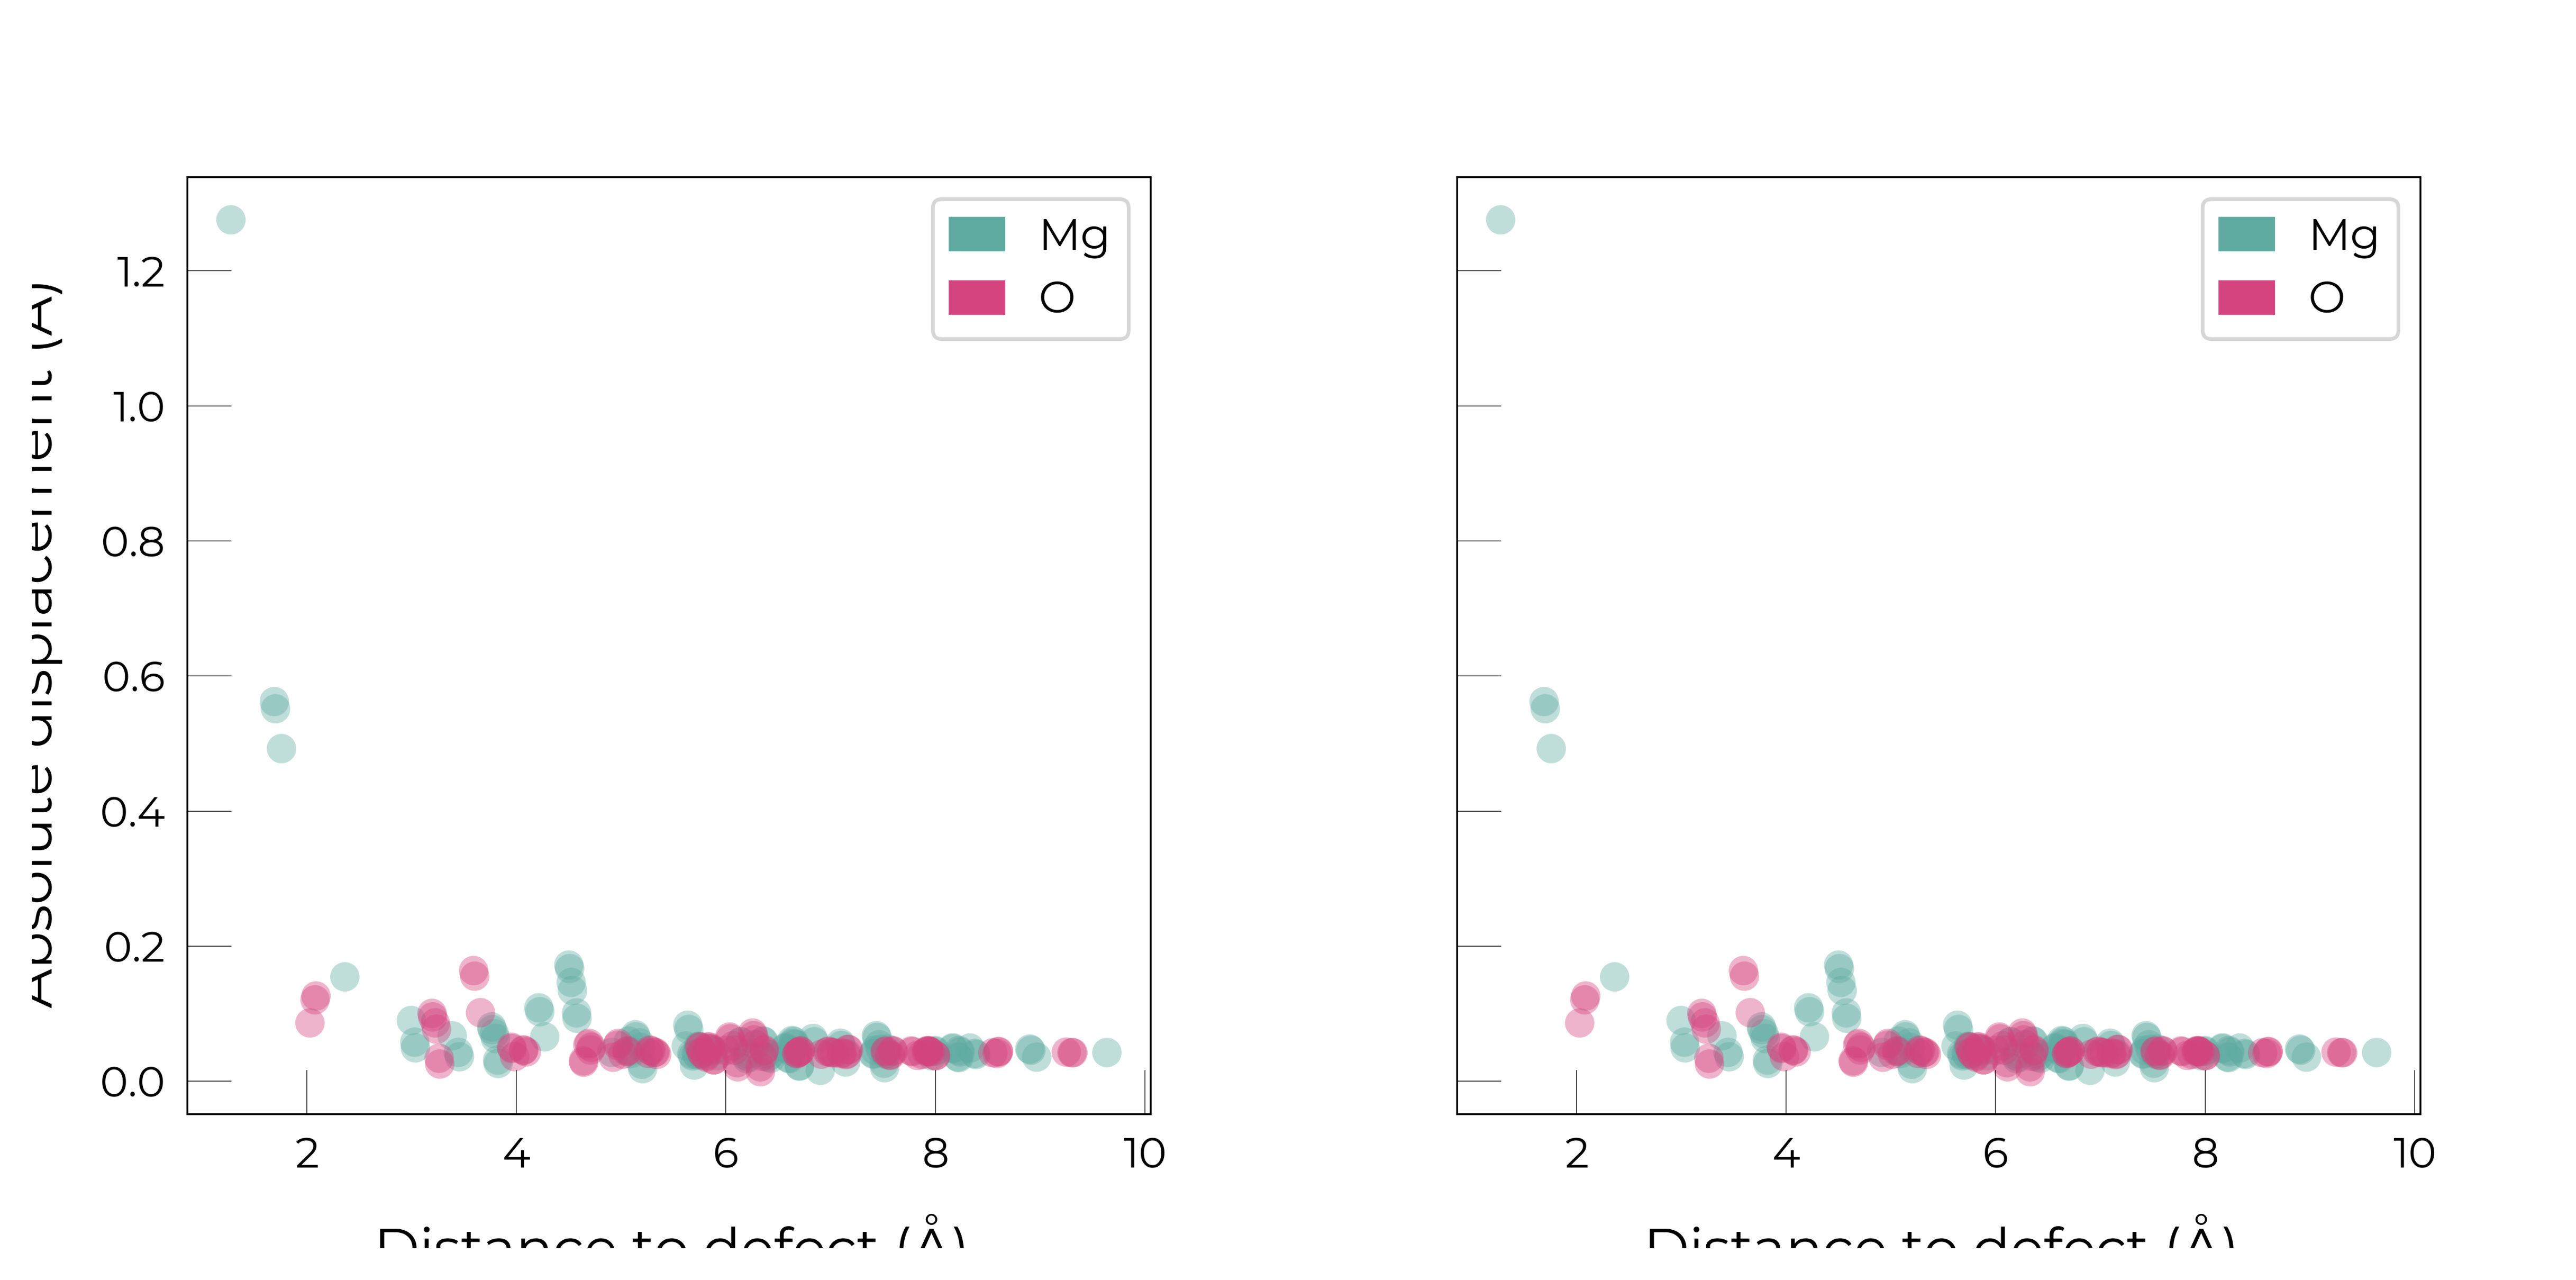

In [36]:
Mg_O_1_VASP = vasp_defect_entry_dict["Mg_O_+1"]
(
    Mg_O_1_eFNV_correction_VASP,
    Mg_O_1_eFNV_plot_VASP
) = Mg_O_1_VASP.get_kumagai_correction(plot=True)

In [ ]:
Mg_O_2_VASP = vasp_defect_entry_dict["Mg_O_+2"]
(
    Mg_O_2_eFNV_correction_VASP,
    Mg_O_2_eFNV_plot_VASP
) = Mg_O_2_VASP.get_kumagai_correction(plot=True)

In [39]:
Mg_O_3_VASP = vasp_defect_entry_dict["Mg_O_+3"]
(
    Mg_O_3_eFNV_correction_VASP,
    Mg_O_3_eFNV_plot_VASP
) = Mg_O_3_VASP.get_kumagai_correction(plot=True)

In [41]:
Mg_O_4_VASP = vasp_defect_entry_dict["Mg_O_+4"]
(
    Mg_O_4_eFNV_correction_VASP,
    Mg_O_4_eFNV_plot_VASP
) = Mg_O_4_VASP.get_kumagai_correction(plot=True)

Site_Symm Defect_Symm  g_Orient  g_Spin  g_Total  Mult
Defect           q                                                        
Mg_O             +4        Oh         C2v      12.0     1.0     12.0   1.0
                 +3        Oh         C3v       8.0     2.0     16.0   1.0
                 +2        Oh         C3v       8.0     1.0      8.0   1.0
                 +1        Oh          Cs      24.0     2.0     48.0   1.0
Mg_O_Unperturbed +1        Oh          Oh       1.0     2.0      2.0   1.0

# Conclusions
1. The broadening factor seems to be dependent on the charge(to some extent) and majorly, the relaxed/unrelaxed state.
2. I can't determine a physical meaning of the broadening factor.

## Unperturbed case separate parsing

In [ ]:
dp_vasp_ENCUT_400 = DefectsParser(
   output_path="MgO/ENCUT_400_Defects/",  # both defect and bulk have ENCUT = 400, consistent with no warnings shown here
   dielectric=dielectric,
   code = 'vasp'
)

In [ ]:
Mg_O_1_unperturbed_VASP = dp_vasp_ENCUT_400.defect_dict["Mg_O_Unrelaxed_+1"]
(
    Mg_O_1_unperturbed_eFNV_correction_VASP,
    Mg_O_1_unperturbed_eFNV_plot_VASP
) = Mg_O_1_unperturbed_VASP.get_kumagai_correction(plot=True)

This matches well with the QE correction value, for the unperturbed defect.

# QE-VASP comparisons

In [47]:
import numpy as np
import matplotlib.pyplot as plt


def _unify_data_limits_across_figures(*figs):
    """Set matching axis indices in each figure to the union of x/y limits."""
    axes_per_fig = [f.get_axes() for f in figs]
    if not axes_per_fig or any(not axs for axs in axes_per_fig):
        return
    n_ax = min(len(axs) for axs in axes_per_fig)
    for i in range(n_ax):
        x0 = min(axs[i].get_xlim()[0] for axs in axes_per_fig)
        x1 = max(axs[i].get_xlim()[1] for axs in axes_per_fig)
        y0 = min(axs[i].get_ylim()[0] for axs in axes_per_fig)
        y1 = max(axs[i].get_ylim()[1] for axs in axes_per_fig)
        for axs in axes_per_fig:
            axs[i].set_xlim(x0, x1)
            axs[i].set_ylim(y0, y1)


def show_side_by_side(fig_left, fig_right, figsize=(8, 5)):
    _unify_data_limits_across_figures(fig_left, fig_right)
    fig_right.axes[0].set_ylabel("")  # drop y-label and tick-labels for fig_right
    fig_right.axes[0].set_yticklabels([])
    fig, axs = plt.subplots(
        1, 2, figsize=figsize, 
        constrained_layout=True,
        gridspec_kw={'wspace': 0}  # decrease wspace to reduce horizontal gap
    )
    for ax, f in zip(axs, (fig_left, fig_right)):
        f.canvas.draw()
        w, h = f.canvas.get_width_height()
        rgb = np.frombuffer(f.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)[..., :3]
        ax.imshow(rgb)
        ax.axis("off")
    plt.show()


array([34.3385, 34.3198, 34.3199, 34.3385, 34.4013, 34.4372, 34.401 ,
       34.4014, 34.4193, 34.419 , 34.4374, 34.419 , 34.4012, 34.2777,
       34.3198, 34.4372, 34.5118, 34.4372, 34.3198, 34.3199, 34.4193,
       34.6189, 34.6175, 34.4189, 34.4374, 34.619 , 34.8042, 34.6174,
       34.5121, 34.618 , 34.6177, 34.4374, 34.4189, 34.3199, 34.3384,
       34.401 , 34.4372, 34.4013, 34.3198, 34.4189, 34.6175, 34.6176,
       34.4189, 34.3385, 34.419 , 34.8042, 35.6677, 34.8033, 34.419 ,
       34.4012, 34.618 , 35.6726, 35.662 , 34.6178, 34.4374, 34.6177,
       34.8033, 34.6174, 34.4014, 34.4189, 34.4188, 34.3384, 34.3198,
       34.401 , 34.4188, 34.4189, 34.4371, 34.6174, 34.8033, 34.6177,
       34.4012, 34.6178, 35.662 , 35.6726, 34.618 , 34.3385, 34.419 ,
       34.8033, 35.6677, 34.8042, 34.419 , 34.3199, 34.4189, 34.6176,
       34.6175, 34.4189, 34.3198, 34.4371, 34.4189, 34.5116, 34.6177,
       34.618 , 34.4371, 34.6174, 34.8042, 34.619 , 34.3198, 34.4189,
       34.6175, 34.6

In [ ]:
show_side_by_side(Mg_O_1_unperturbed_eFNV_plot_QE, Mg_O_1_unperturbed_eFNV_plot_VASP)

In [50]:
show_side_by_side(Mg_O_1_eFNV_plot_QE, Mg_O_1_eFNV_plot_VASP)

np.float64(3.1186)

In [51]:
show_side_by_side(Mg_O_2_eFNV_plot_QE, Mg_O_2_eFNV_plot_VASP)

O site potential difference, minus average offset:  [-0.015 -0.022 -0.022 -0.019 -0.009 -0.02  -0.008 -0.009 -0.012 -0.011
 -0.02  -0.012 -0.009 -0.017 -0.021 -0.016  0.067 -0.016 -0.021 -0.021
 -0.035 -0.074 -0.074 -0.034 -0.017 -0.074  0.096 -0.073  0.067 -0.074
 -0.073 -0.016 -0.034 -0.021 -0.015  0.014 -0.017  0.014 -0.022 -0.025
  0.069  0.069 -0.025 -0.016 -0.025 -0.073  0.491 -0.073 -0.025  0.013
  0.069  0.491  0.491  0.069 -0.017  0.069 -0.073  0.069  0.013 -0.025
 -0.025 -0.018 -0.018 -0.009 -0.025 -0.025 -0.02   0.01   0.035  0.01
 -0.009  0.01  -0.201 -0.201  0.01  -0.019 -0.025  0.035 -0.201  0.035
 -0.025 -0.018 -0.025  0.01   0.01  -0.025 -0.021 -0.016 -0.006  0.067
 -0.002 -0.002 -0.016 -0.001 -0.029 -0.002 -0.021 -0.006 -0.002 -0.002
 -0.006  0.013 -0.017 -0.018  0.013 -0.018 -0.018 -0.018]
Mg site potential difference, minus average offset:  [-0.025  0.004  0.004 -0.037 -0.002 -0.036 -0.005 -0.002 -0.002  0.027
 -0.037  0.027 -0.005 -0.005 -0.071  0.285 -0.071 -0.004 

In [ ]:
show_side_by_side(Mg_O_3_eFNV_plot_QE, Mg_O_3_eFNV_plot_VASP)

In [53]:
show_side_by_side(Mg_O_4_eFNV_plot_QE, Mg_O_4_eFNV_plot_VASP)

O site potential difference, minus average offset:  [-0.02  -0.02  -0.02  -0.02  -0.019 -0.018 -0.019 -0.019 -0.018 -0.017
 -0.018 -0.017 -0.019 -0.02  -0.02  -0.018 -0.018 -0.018 -0.02  -0.02
 -0.018 -0.016 -0.015 -0.017 -0.018 -0.016 -0.01  -0.015 -0.018 -0.015
 -0.015 -0.018 -0.017 -0.02  -0.019 -0.019 -0.018 -0.019 -0.02  -0.017
 -0.015 -0.015 -0.017 -0.02  -0.017 -0.01   0.296 -0.009 -0.017 -0.019
 -0.015  0.291  0.301 -0.015 -0.018 -0.015 -0.009 -0.015 -0.019 -0.017
 -0.017 -0.019 -0.02  -0.019 -0.017 -0.017 -0.018 -0.015 -0.009 -0.015
 -0.019 -0.015  0.301  0.291 -0.015 -0.02  -0.017 -0.009  0.296 -0.01
 -0.017 -0.02  -0.017 -0.015 -0.015 -0.017 -0.02  -0.018 -0.017 -0.017
 -0.015 -0.015 -0.018 -0.015 -0.01  -0.016 -0.02  -0.017 -0.015 -0.016
 -0.018 -0.019 -0.018 -0.017 -0.019 -0.017 -0.018 -0.02 ]
Mg site potential difference, minus average offset:  [ 0.004  0.004  0.004  0.002  0.006  0.002  0.004  0.006  0.006  0.007
  0.002  0.007  0.004  0.004  0.006  0.011  0.005  0.004  

General conclusion: QE correction plots are currently far noisier/variable than VASP correction plots.

Used AI to help with the subplots

# Comparing correction energies

In [56]:
import pandas as pd
charges = [1,2,3,4]

corrections_qe = [Mg_O_1_eFNV_correction_QE, Mg_O_2_eFNV_correction_QE, Mg_O_3_eFNV_correction_QE, Mg_O_4_eFNV_correction_QE]
corrections_vasp = [Mg_O_1_eFNV_correction_VASP, Mg_O_2_eFNV_correction_VASP, Mg_O_3_eFNV_correction_VASP, Mg_O_4_eFNV_correction_VASP]

df = pd.DataFrame({
    "Charge:": charges, 
    "Correction_VASP:": [round(i.correction_energy, 3) for i in corrections_vasp], 
    "Correction_QE:": [round(i.correction_energy, 3) for i in corrections_qe ]
})
df["ΔCorrection (eV)"] = abs(df["Correction_VASP:"] - df["Correction_QE:"])
df["ΔCorrection (%)"] = round(abs(df["ΔCorrection (eV)"] / df["Correction_VASP:"]) * 100, 1)
df

         47448 function calls (47441 primitive calls) in 4.040 seconds

   Ordered by: cumulative time
   List reduced from 316 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.099    0.050    3.946    3.946 /var/folders/r3/7gb7wqtd0k9dgwpnkz2jmy_80000gn/T/ipykernel_56713/1480256120.py:39(interpolate_potentials_at_atomic_sites)
      2/1    0.001    0.000    3.840    3.840 /Users/kavanase/miniconda3/lib/python3.13/site-packages/scipy/interpolate/_rgi.py:288(__init__)
        1    0.031    0.031    3.840    3.840 /Users/kavanase/miniconda3/lib/python3.13/site-packages/scipy/interpolate/_rgi.py:336(_construct_spline)
        1    0.110    0.110    3.809    3.809 /Users/kavanase/miniconda3/lib/python3.13/site-packages/scipy/interpolate/_ndbspline.py:444(make_ndbspl)
        1    0.000    0.000    2.056    2.056 /Users/kavanase/miniconda3/lib/python3.13/site-packages/scipy/interpolate/_ndbspline.py:216(design_matrix)
    

### Sources of error during potential averaging

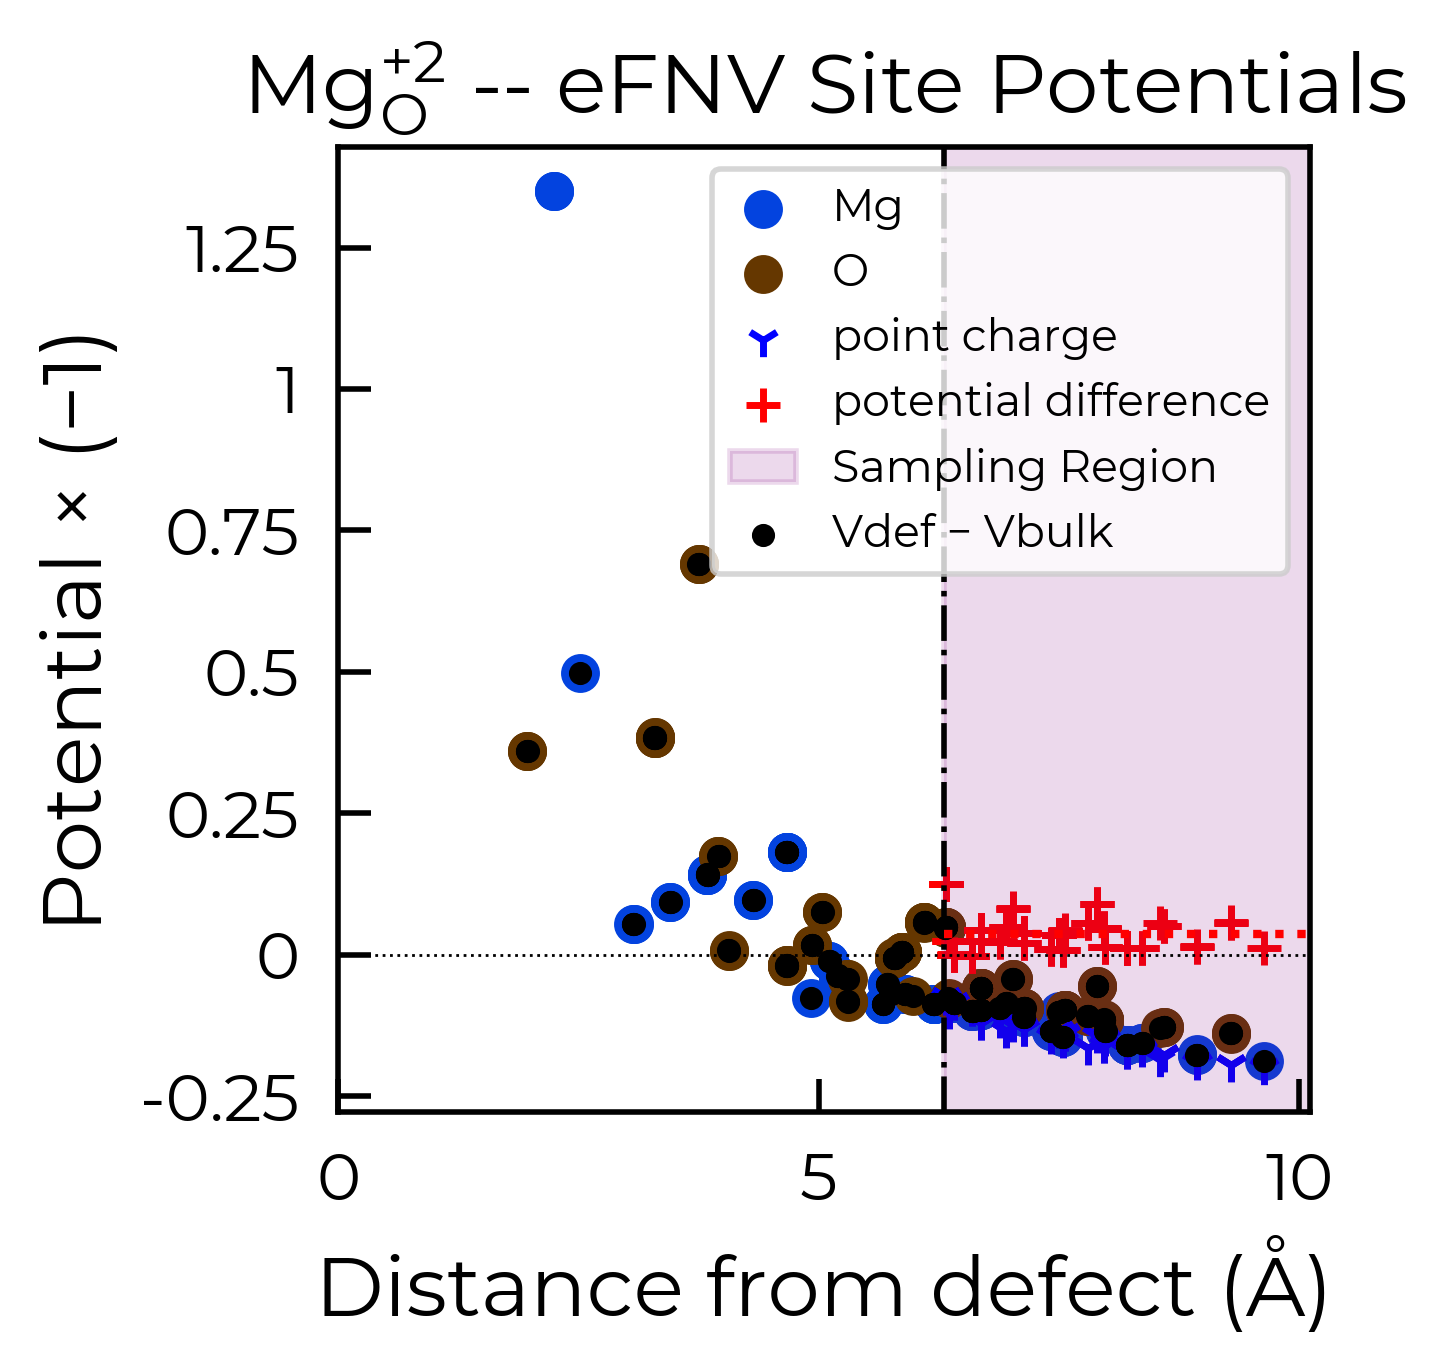

In [8]:
Mg_O_2_disp_plot_VASP = Mg_O_2_VASP.plot_site_displacements()

In [70]:
Mg_O_2_disp_plot_QE = Mg_O_2_QE.plot_site_displacements()

,QE doped distance,QE sxd distance,QE doped Vdef - Vbulk,QE sxd Vdef - Vbulk,QE sxd potential
108,0.000,0.000,5.219,0.000,0.000
134,1.967,0.000,0.360,0.000,0.000
129,1.967,0.000,0.360,0.000,0.000
130,1.967,0.000,0.360,0.000,0.000
52,2.249,1.964,1.350,0.360,0.360
46,2.249,1.967,1.351,0.360,0.360
51,2.249,1.973,1.350,0.360,0.360
26,2.511,2.513,0.498,0.498,0.498
78,3.072,3.068,0.054,0.054,0.054
73,3.072,3.070,0.054,0.054,0.054


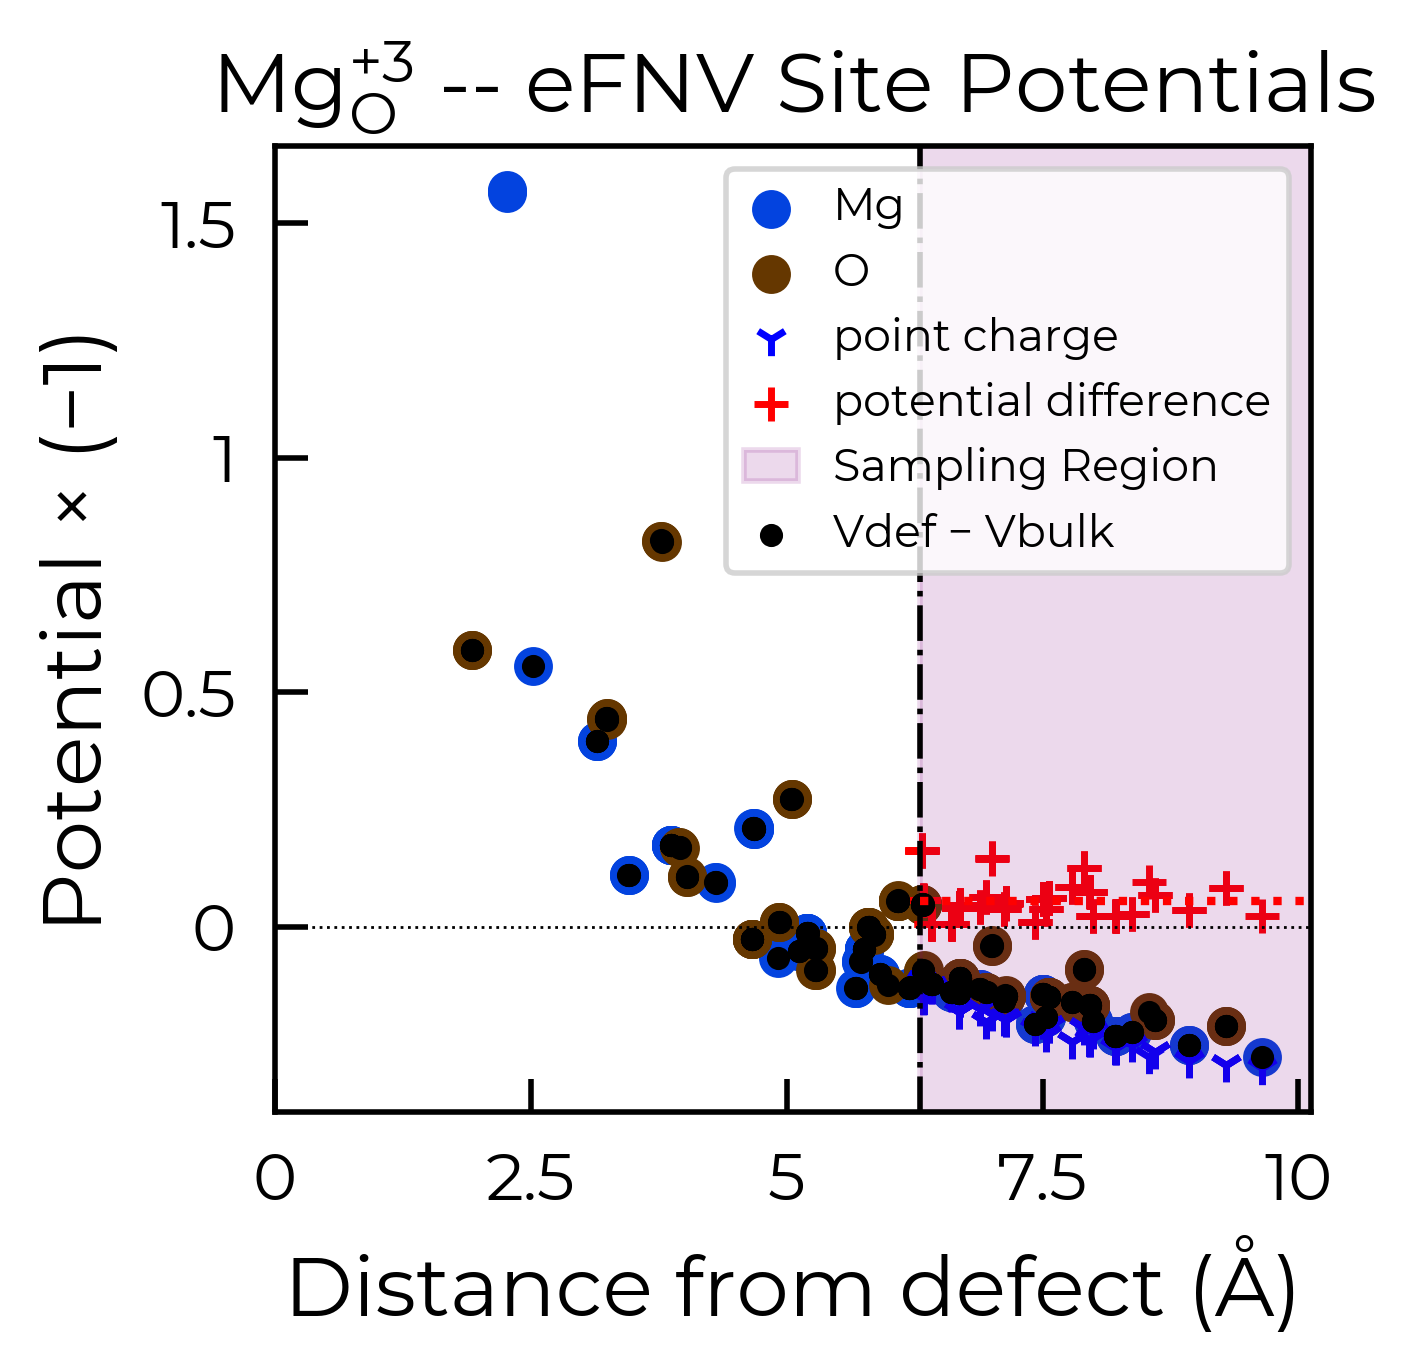

In [71]:
show_side_by_side(Mg_O_2_disp_plot_QE, Mg_O_2_disp_plot_VASP)

In [ ]:
assert Mg_O_2_VASP.defect_supercell == Mg_O_2_QE.defect_supercell

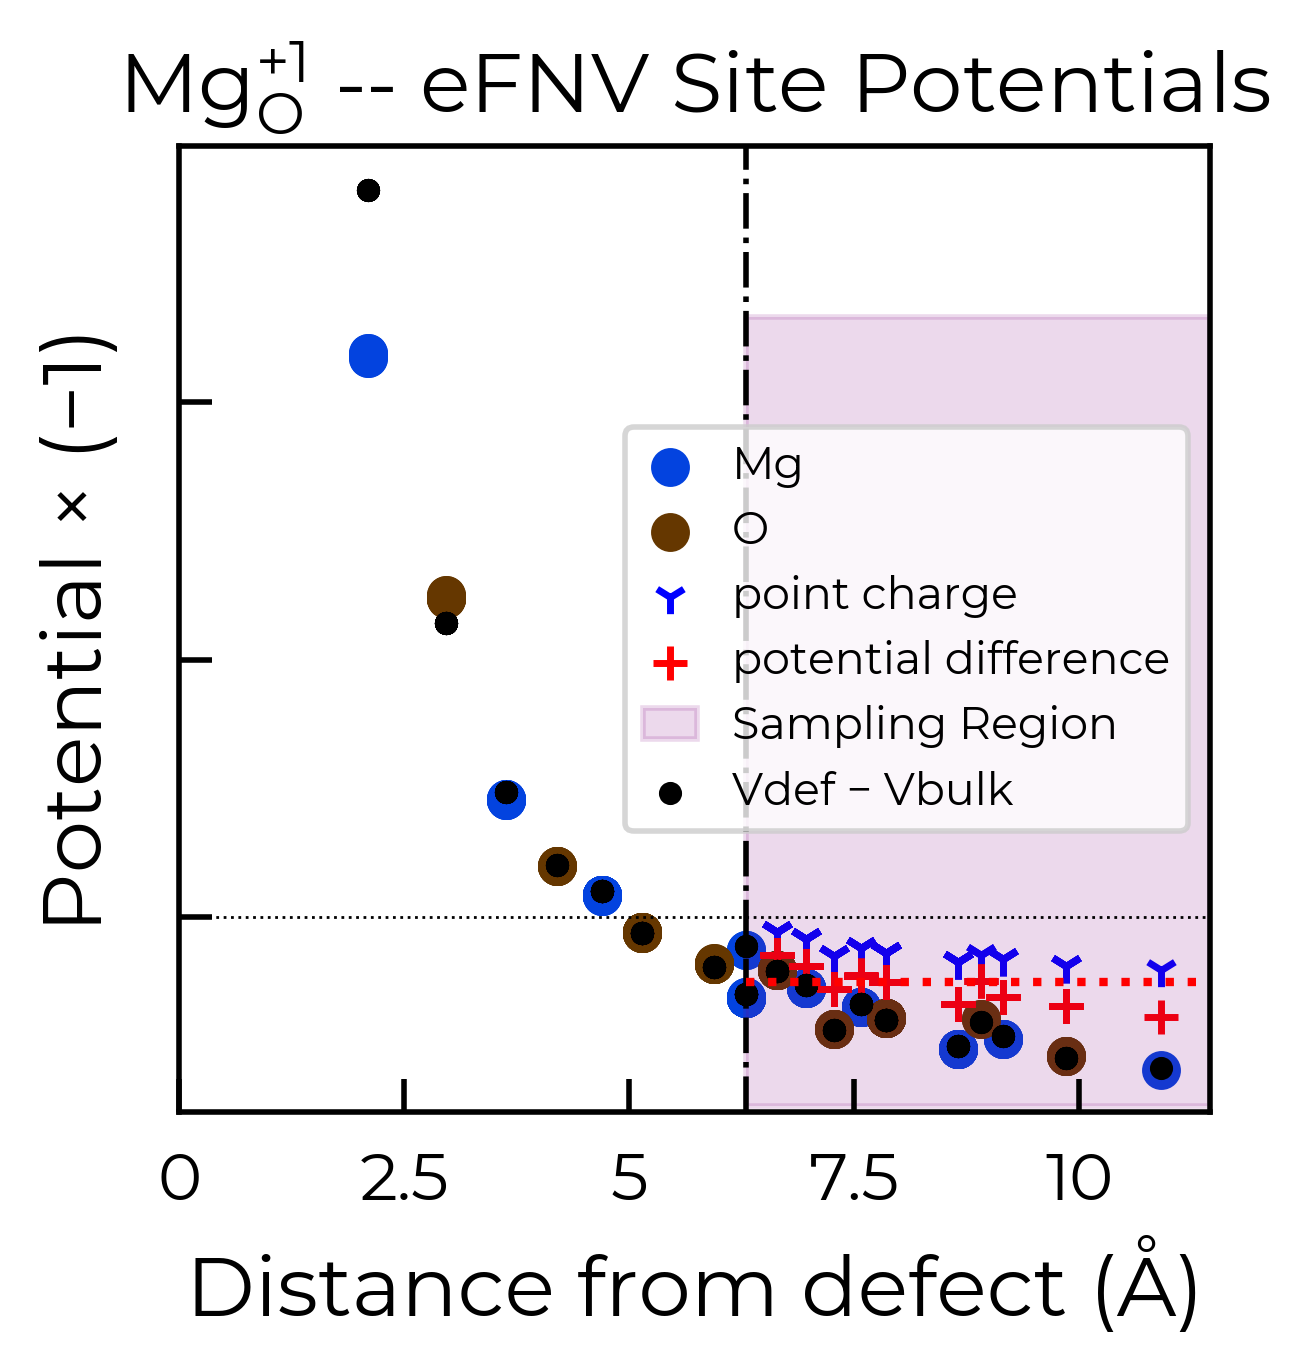

In [74]:
from pymatgen.io.espresso.outputs import PWxml
from pymatgen.io.vasp.outputs import Vasprun
defect_qe = PWxml("../tests/data/espresso/MgO_qe/Mg_O_+2/espresso_std/espresso.xml")
defect_vasp = Vasprun("MgO/Defects/Mg_O_+2/vasp_std/vasprun.xml.gz")
defect_qe_cube = VolumetricData.from_cube("../tests/data/espresso/MgO_qe/Defects/Mg_O_+2/espresso_std/Mg_O_+2.cube")


Setting up multiprocessing:  20%|██        | 1/5 [00:13<00:54, 13.52s/it]              

Calculated Kumagai (eFNV) correction is 0.277 eV


Setting up multiprocessing: 100%|██████████| 5/5 [00:42<00:00,  8.43s/it]

Calculated Kumagai (eFNV) correction is 2.225 eV
Calculated Kumagai (eFNV) correction is 0.115 eV
Calculated Kumagai (eFNV) correction is 0.557 eV
Calculated Kumagai (eFNV) correction is 1.295 eV



analysis.py:5098: UserWarning: [PARSED_WITH_WARNING] Folder: Mg_O_Unperturbed_+1 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+4 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+1 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+2 | Warning: Projected magnetisation not implemented for QE. Returning None.

[PARSED_WITH_WARNING] Folder: Mg_O_+3 | Warning: Projected magnetisation not implemented for QE. Returning None.


Calculated Kumagai (eFNV) correction is 0.115 eV


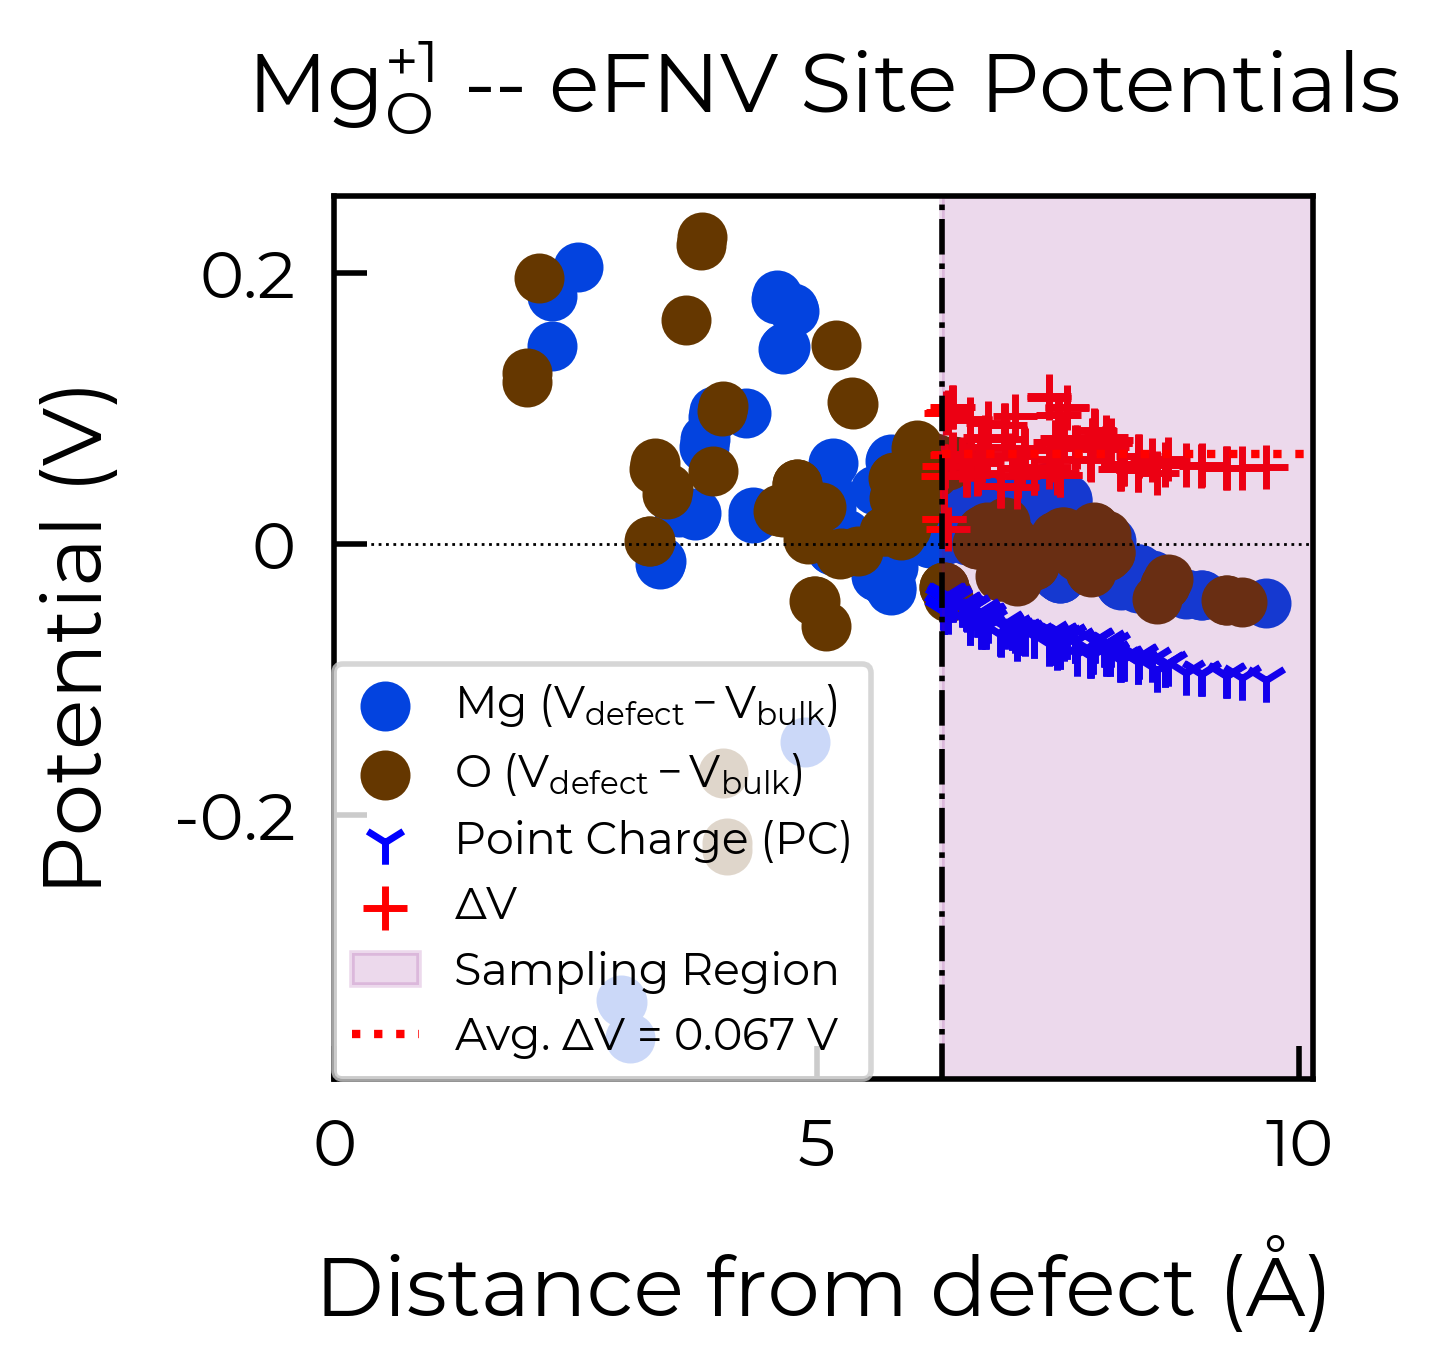

In [76]:
# structure definitions consistent:
assert defect_vasp.final_structure == defect_qe_cube.structure
assert defect_qe_cube.structure == defect_qe.final_structure
assert defect_qe_cube.structure == Mg_O_2_QE.defect_supercell

In [78]:
thermo_VASP = dp_vasp.get_defect_thermodynamics()
thermo_VASP.get_symmetries_and_degeneracies()

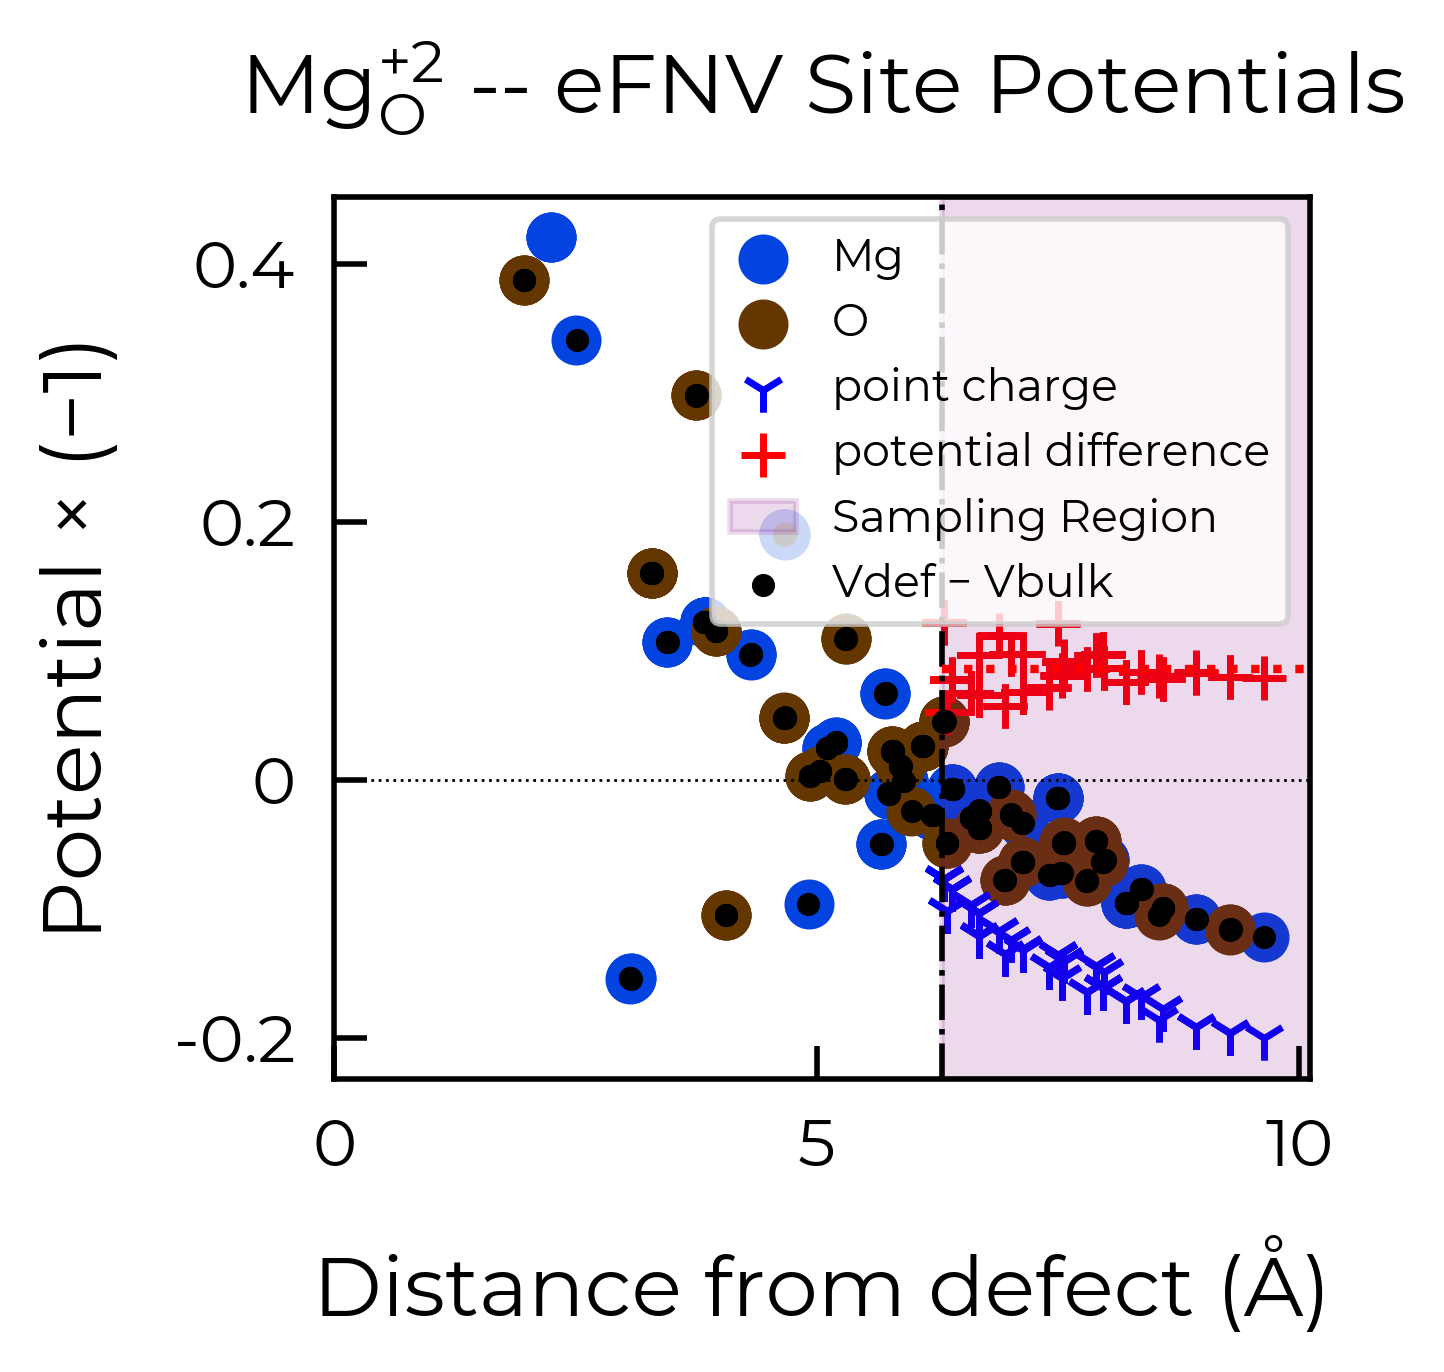

In [80]:
thermo_QE = dp.get_defect_thermodynamics(band_gap=thermo_VASP.band_gap)
thermo_QE.get_symmetries_and_degeneracies()

As we see, there is symmetry in the relaxed defect structures (i.e. not `C1` point symmetries), and so we expect some degeneracy in the site potentials as a result. We see this in the VASP results but not the QE results.

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)

Mg_O_2_eFNV_correction_data_QE = Mg_O_2_eFNV_correction_QE.metadata["pydefect_ExtendedFnvCorrection"]
data_qe = [
    {
        "espresso specie": s.specie,
        "espresso distance": round(float(s.distance), 3),
        "espresso potential": round(float(s.potential), 3),
        "espresso pc_potential": round(float(s.pc_potential), 3) if s.pc_potential is not None else None
    }
    for s in Mg_O_2_eFNV_correction_data_QE.sites
]

Mg_O_2_eFNV_correction_data_VASP = Mg_O_2_eFNV_correction_VASP.metadata["pydefect_ExtendedFnvCorrection"]
data_vasp = [
    {
        "VASP specie": s.specie,
        "VASP distance": round(float(s.distance), 3),
        "VASP potential": round(float(s.potential), 3),
        "VASP pc_potential": round(float(s.pc_potential), 3) if s.pc_potential is not None else None
    }
    for s in Mg_O_2_eFNV_correction_data_VASP.sites
]

# order columns to put espresso and VASP specie together, then distance, then potential, then pc_potential:
df = pd.DataFrame(
    [{**q, **v} for q, v in zip(data_qe, data_vasp)],
)
df = df[["espresso specie", "VASP specie", "espresso distance", "VASP distance", "espresso potential", "VASP potential", "espresso pc_potential", "VASP pc_potential"]]
# sort by espresso distance:
df = df.sort_values(by="espresso distance", ascending=True)
df



In [ ]:
# compare df_qe and df_vasp
combined_df = df.copy()
combined_df["ΔDistance (Å)"] = round(abs(combined_df["espresso distance"] - combined_df["VASP distance"]), 3)
combined_df["ΔPotential (eV)"] = round(abs(combined_df["espresso potential"] - combined_df["VASP potential"]), 3)
combined_df["ΔPC Potential (eV)"] = round(abs(combined_df["espresso pc_potential"] - combined_df["VASP pc_potential"]), 3)
# sort by ΔDistance (Å):
combined_df = combined_df.sort_values(by="espresso distance", ascending=True)
combined_df


Evidently it is the site potentials which differ, the structure definition (giving rise to `distance` and `pc_potential` here) are consistent.

We have symmetry/degeneracy breaking in the QE results, which we don't have with VASP (or with far lower magnitude), for sites at the same distance from the defect (i.e. symmetry-equivalent sites). These should ideally have the same site potentials, regardless of averaging procedure.

Interestingly, the magnitude of the QE symmetry breaking seems to _increase_ with distance from the defect site, and so strongly affecting the charge correction (as extracted from the site potential differences in the sampling region far from the defect).

Changing to cubic interpolation reduces but does not remove the symmetry breaking here.

Parsing v_Sb_-3/espresso_std: 100%|██████████| 1/1 [00:21<00:00, 21.21s/it]
analysis.py:5102: UserWarning: [PARSED_WITH_WARNING] Folder: v_Sb_-3 | Warning: Projected magnetisation not implemented for QE. Returning None.
Static dielectric constant not implemented for QE. Returning None.
Static dielectric constant without local field effects not implemented for QE. Returning None.
Ionic part of the static dielectric constant not implemented for QE. Returning None.
CBM and band_gap are infinite, which can cause downstream failures. Reverting to use of bulk supercell calculation for band edge extrema.Add extra bands using the 'nbnd' parameter


## Comparing sxdefectalign vasp and QE results

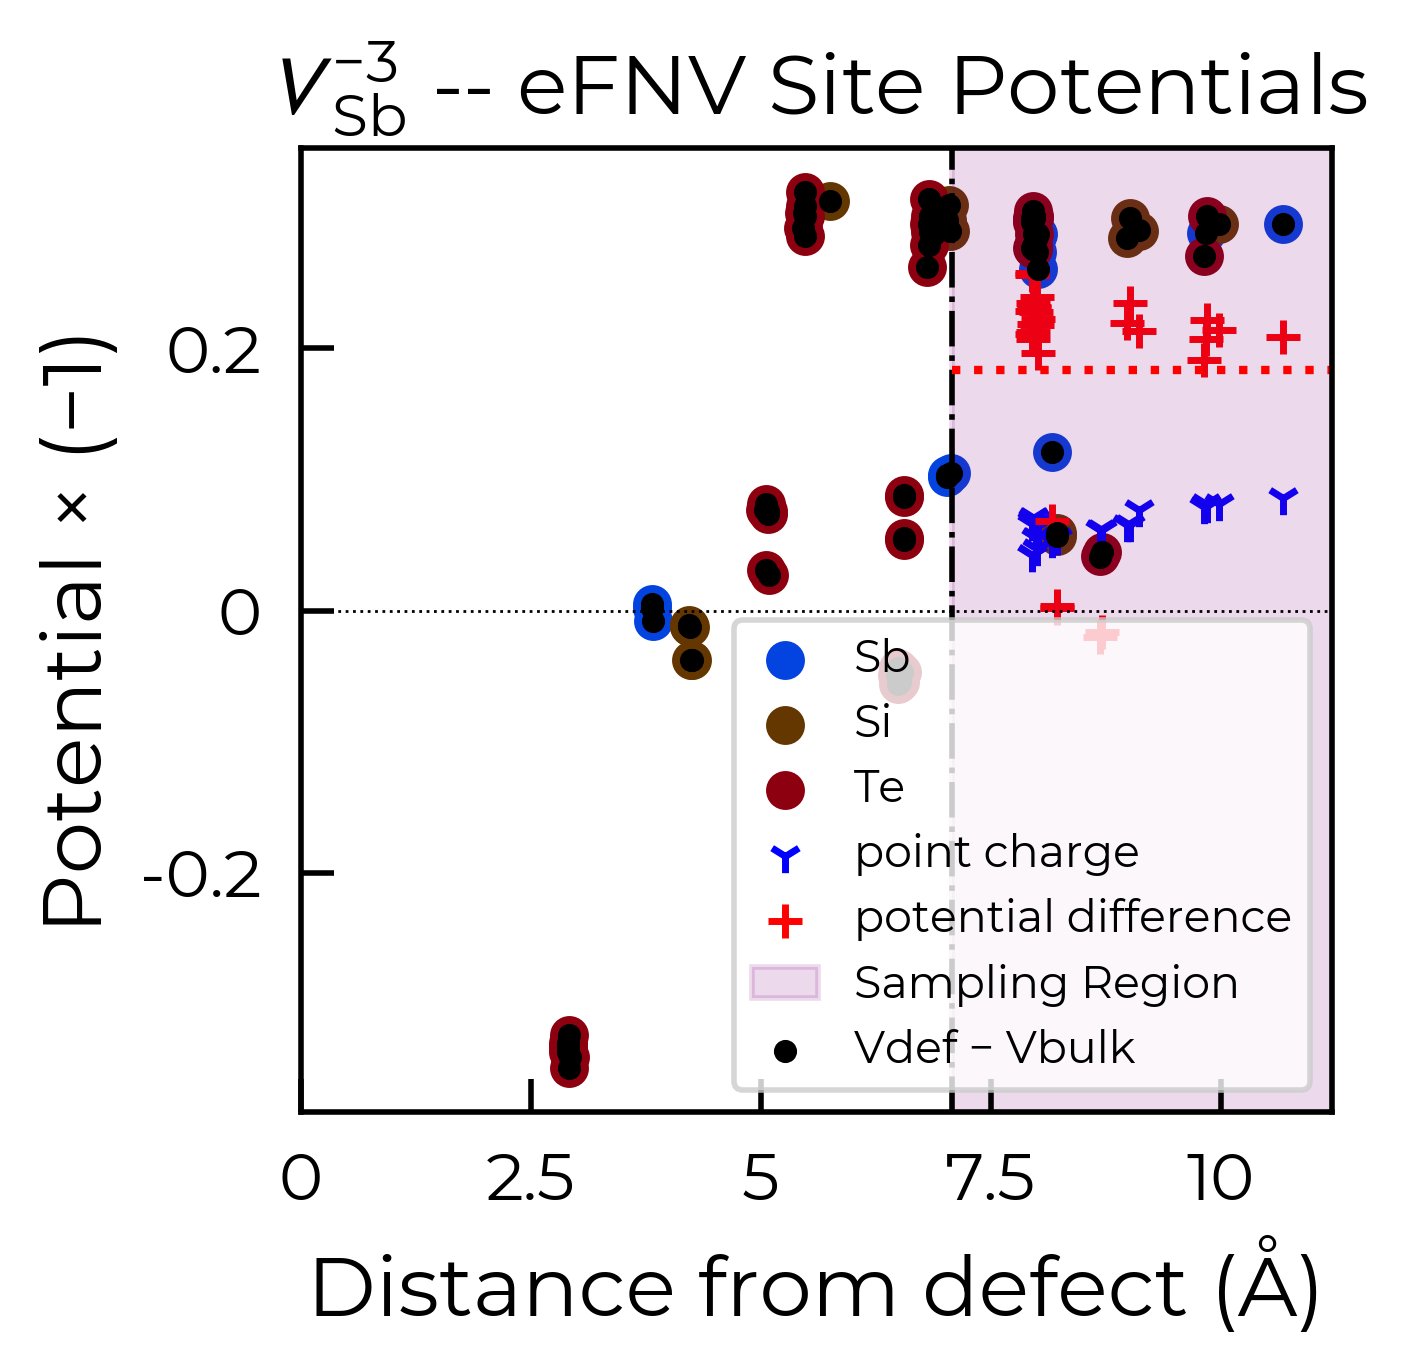

In [11]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+1_unperturbed/vAtoms.dat"
)

# prepare data
x_qe  = data_qe[:, 0] * 0.529177   # Distance (Å)
y1_qe = -data_qe[:, 2]          # Vdef - Vbulk
y2_qe = -data_qe[:, 3]          # Vdef - Vbulk - Vlr
y3_qe = -data_qe[:, 1]          # Vlr


ax.scatter(x_qe, y1_qe, label="Vdef − Vbulk_QE", s =10, color = "green")
#ax.scatter(x_qe, y2_qe, label="Vdef − Vbulk − Vlr_QE", s = 10, color = "green")
#ax.scatter(x_qe, y3_qe, label="Vlr", s =10, color = "black")


data_vasp = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_vasp/Mg_O_+1_unperturbed/vAtoms.dat"
)

# prepare data
x_vasp  = data_vasp[:, 0] * 0.529177   # Distance (Å)
y1_vasp = -data_vasp[:, 2]          # Vdef - Vbulk
y2_vasp = -data_vasp[:, 3]          # Vdef - Vbulk - Vlr
y3_vasp = -data_vasp[:, 1]          # Vlr

ax.scatter(x_vasp, y1_vasp, label="Vdef − Vbulk_VASP", s =10, color = "blue")
#ax.scatter(x_vasp, y2_vasp, label="Vdef − Vbulk − Vlr_VASP", s = 10, color = "blue")
#ax.scatter(x_vasp, y3_vasp, label="Vlr", s =10, color = "black")


ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")
ax.legend(fontsize =8)


ax.legend()
ax.figure.canvas.draw_idle()


plt.show()


There is a slight difference here. Note that grid the mesh is slightly different $(168 \times 168 \times 168)$(VASP) and $(160 \times 160 \times 160)$ (QE)

## Comparing site potentials (bulk and defect)

In [12]:
Mg_O_1_unperturbed_QE.calculation_metadata["defect_site_potentials"]

In [14]:
Mg_O_1_unperturbed_QE.calculation_metadata["bulk_site_potentials"]

Calculated Kumagai (eFNV) correction is 1.077 eV


core.py:289: UserWarning: Estimated error in the Kumagai (eFNV) charge correction for defect v_Sb_-3 is 0.067 eV (i.e. which is greater than the `error_tolerance`: 0.050 eV). You may want to check the accuracy of the correction by plotting the site potential differences (using `defect_entry.get_kumagai_correction()` with `plot=True`). Large errors are often due to unstable or shallow defect charge states (which can't be accurately modelled with the supercell approach; see https://doped.readthedocs.io/en/latest/Tips.html#perturbed-host-states-shallow-defects). If this error is not acceptable, you may need to use a larger supercell for more accurate energies.


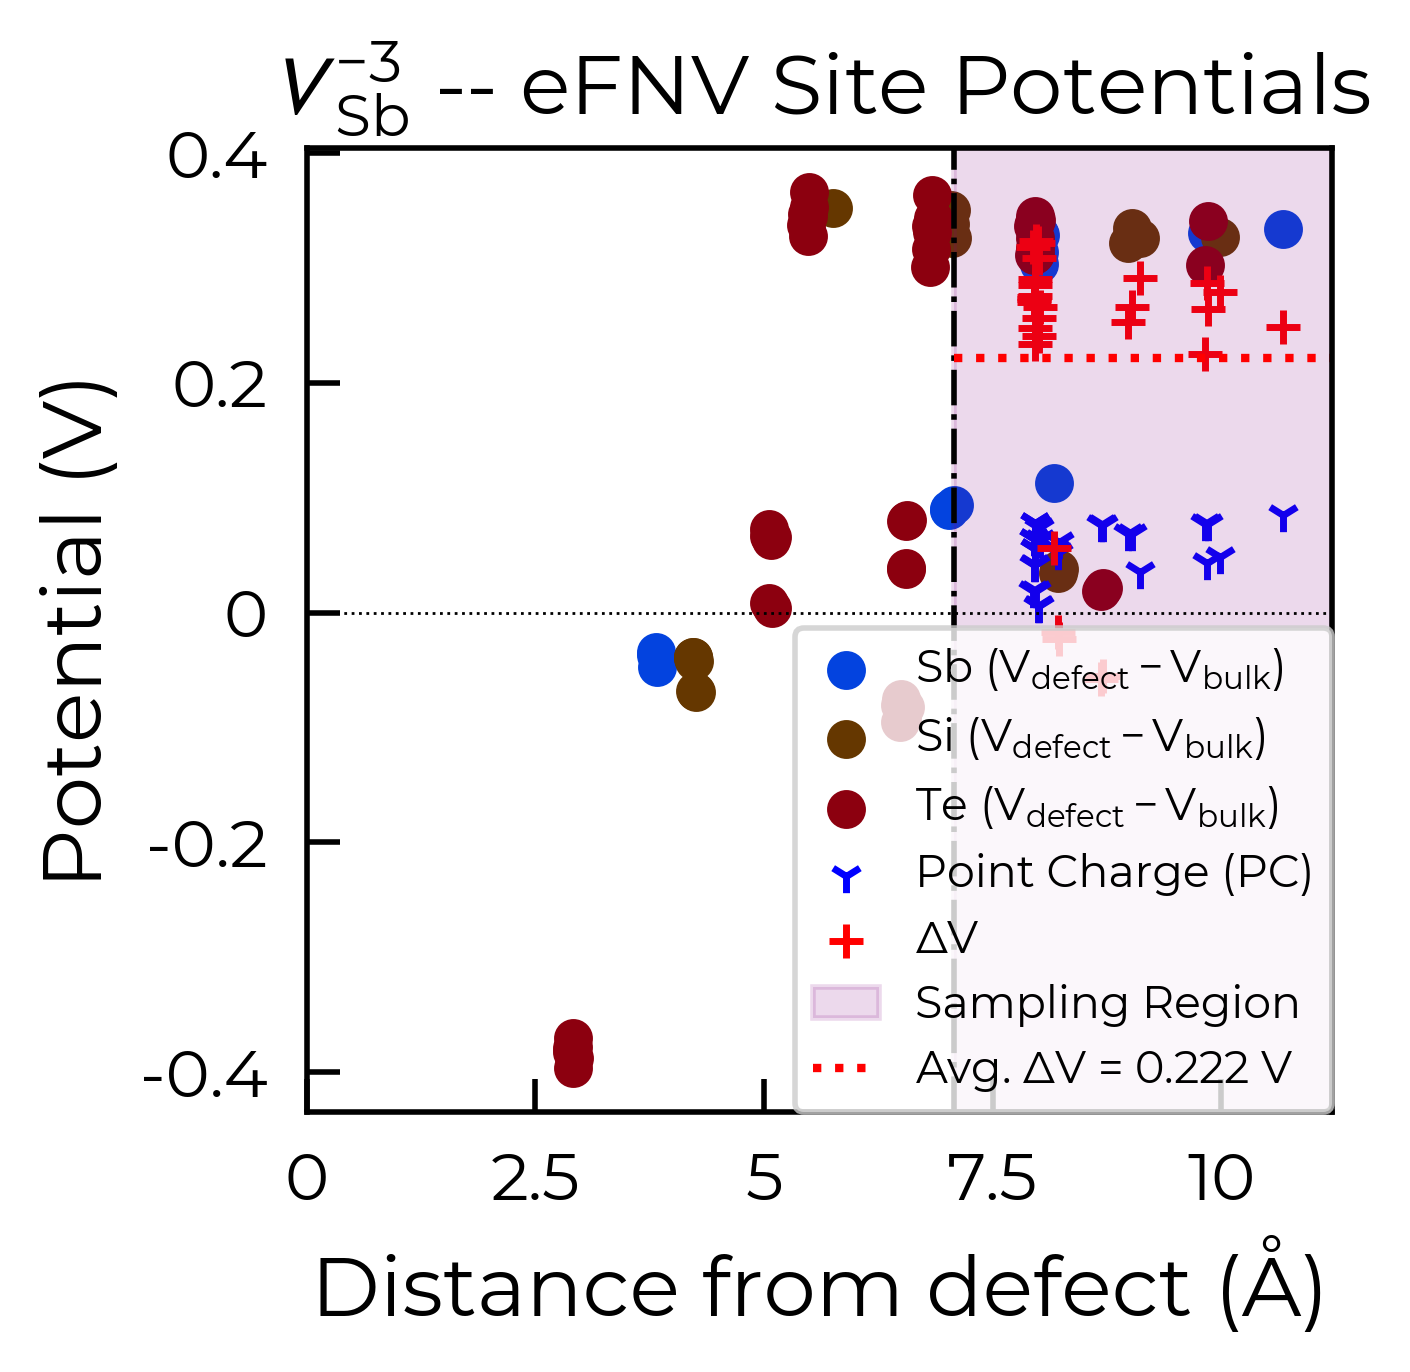

In [16]:
Mg_O_1_unperturbed_VASP.calculation_metadata["defect_site_potentials"]

In [23]:
Mg_O_1_unperturbed_VASP.calculation_metadata["bulk_site_potentials"]

Different magnitudes, but mostly consistent differences in the site potentials, when comparing VASP to QE

In [21]:
Mg_O_1_unperturbed_QE.calculation_metadata["vbm"]

,doped distance,doped Vdef-Vbulk,sxd distance,sxd Vdef-Vbulk,doped - sxd
0,2.902,-0.333,2.902,-0.333,0.000
1,2.903,-0.337,2.903,-0.336,-0.001
2,2.907,-0.330,2.907,-0.330,0.000
3,2.912,-0.349,2.913,-0.324,-0.025
4,2.913,-0.324,2.913,-0.349,0.025
5,2.926,-0.340,2.925,-0.340,0.000
6,3.818,0.005,3.818,0.005,0.000
7,3.818,0.002,3.818,0.002,0.000
8,3.826,-0.008,3.826,-0.008,0.000
9,4.220,-0.012,4.220,-0.012,0.000


In [1]:
Mg_O_1_unperturbed_VASP.calculation_metadata["vbm"]

### Comparing doped-QE and doped-VASP site potentials for defect vs bulk

In [5]:
defect_site_potentials_diff = np.round(
    Mg_O_2_QE.calculation_metadata["defect_site_potentials"] - Mg_O_2_VASP.calculation_metadata["defect_site_potentials"]
, 3)
average_O_site_potentials_diff = np.mean(defect_site_potentials_diff[:108])  # first 108 sites are O sites
average_Mg_site_potentials_diff = np.mean(defect_site_potentials_diff[109:])

# skip 108th site, it's the anti-site
print("O site potential difference, minus average offset: ", np.round(defect_site_potentials_diff[:108] - average_O_site_potentials_diff, 3))
print("Mg site potential difference, minus average offset: ", np.round(defect_site_potentials_diff[109:] - average_Mg_site_potentials_diff, 3))

In [ ]:
bulk_site_potentials_diff = np.round(
    Mg_O_2_QE.calculation_metadata["bulk_site_potentials"] - Mg_O_2_VASP.calculation_metadata["bulk_site_potentials"]
, 3)
average_O_site_potentials_diff = np.mean(bulk_site_potentials_diff[:108])  # first 108 sites are O sites
average_Mg_site_potentials_diff = np.mean(bulk_site_potentials_diff[108:])

print("O site potential difference, minus average offset: ", np.round(bulk_site_potentials_diff[:108] - average_O_site_potentials_diff, 3))
print("Mg site potential difference, minus average offset: ", np.round(bulk_site_potentials_diff[108:] - average_Mg_site_potentials_diff, 3))

Ok, clear numerical rounding issues here (though likely not the core issue). This is the result of using `linear` interpolation in `interpolate_potentials_at_atomic_sites`, switching to `cubic` fixes this from tests – but makes the interpolation much slower (though using a vectorised implementation as added now speeds this up at least 2x, can think about further optimisations later).

Update: With `cubic` interpolation, the bulk site potential differences (minus average offset) are now all zero as expected, leaving the defect site potential differences as the only remaining source of error.

In [ ]:
defect_site_potentials_diff = np.round(
    Mg_O_1_unperturbed_QE.calculation_metadata["defect_site_potentials"] - Mg_O_1_unperturbed_VASP.calculation_metadata["defect_site_potentials"]
, 3)
average_O_site_potentials_diff = np.mean(defect_site_potentials_diff[:108])  # first 108 sites are O sites
average_Mg_site_potentials_diff = np.mean(defect_site_potentials_diff[109:])

# skip 108th site, it's the anti-site
print("O site potential difference, minus average offset: ", np.round(defect_site_potentials_diff[:108] - average_O_site_potentials_diff, 3))
print("Mg site potential difference, minus average offset: ", np.round(defect_site_potentials_diff[109:] - average_Mg_site_potentials_diff, 3))

So the issue is with the extraction of the site potentials for the defect supercell, which is numerically noisy and particularly worse in the case of relaxed defect structures.

Note: It's only sites far from the defect which are showing the symmetry breaking, suggesting that it's some boundary issue! 

Found the issue with the help of Claude, pointing it to this issue:
>Root cause: The grid runs from 0 to 1 - 1/n (endpoint=False), but sites can have fractional coordinates anywhere in [0, 1). The old code clipped coordinates to [0, x_max], so any site with a frac_coord between x_max and 1.0 got snapped to x_max. Cubic interpolation also needs neighboring points beyond the boundary, so even sites slightly inside the grid edge got incorrect values. This is why symmetry-equivalent sites far from the defect (near cell edges) gave different potentials.

>Fix: Pad the potential grid with one periodic image on each side along all three axes. The interpolation grid now extends from -1/n to 1.0, so all coordinates in [0, 1) fall well within the interpolation domain with proper periodic neighbors available. The np.clip call is no longer needed.

Using updated code now gives the correct matching site potentials:

In [ ]:
import numpy as np

cube_path = "../tests/data/espresso/MgO_qe/Defects/Mg_O_+2/espresso_std/Mg_O_+2.cube"

from doped.utils.parsing import Ry_to_eV, RegularGridInterpolator, BOHR_TO_ANGSTROM

def _get_atomic_site_potentials(cube_path, beta: float = 1.5):
    """
    Calculates atomic gaussian average site potential.

    cube_path:  cube path for the potential

    beta : Gaussian broadening factor at atomic sites (in bohr)

    Returns:
            dict with keys:
                atomic sites
                Positions
                site_potential
    """
    cube_data = VolumetricData.from_cube(cube_path)
    nx, ny, nz = cube_data.data["total"].shape
    lattice = cube_data.structure.lattice

    reci_latt = lattice.reciprocal_lattice
    # Integer Miller indices along each reciprocal axis, FFT-ordered:
    nx_idx = np.roll(np.arange(-nx // 2, nx // 2, 1, dtype=int), int(nx // 2))
    ny_idx = np.roll(np.arange(-ny // 2, ny // 2, 1, dtype=int), int(ny // 2))
    nz_idx = np.roll(np.arange(-nz // 2, nz // 2, 1, dtype=int), int(nz // 2))

    Nx, Ny, Nz = np.meshgrid(nx_idx, ny_idx, nz_idx, indexing="ij")
    # G = n1*b1 + n2*b2 + n3*b3; compute |G|^2 using the reciprocal metric tensor
    # to correctly handle non-orthorhombic cells:
    recip_matrix = reci_latt.matrix  # rows are b1, b2, b3
    metric = recip_matrix @ recip_matrix.T  # G_ij = bi . bj
    g2 = (
        Nx**2 * metric[0, 0]
        + Ny**2 * metric[1, 1]
        + Nz**2 * metric[2, 2]
        + 2 * Nx * Ny * metric[0, 1]
        + 2 * Nx * Nz * metric[0, 2]
        + 2 * Ny * Nz * metric[1, 2]
    )

    pot = cube_data.data["total"] * -Ry_to_eV
    v_G = np.fft.fftn(pot)
    beta_angstrom = beta * BOHR_TO_ANGSTROM  # TODO: Just use beta in units of Angstrom later?
    v_G *= np.exp(-0.5 * (beta_angstrom**2) * g2)  # Gaussian broadening in reciprocal space
    v_R = np.real(np.fft.ifftn(v_G))

    v_R_atomic_sites = interpolate_potentials_at_atomic_sites(v_R, cube_data)

    sites = cube_data.structure.sites
    coords = np.array([site.coords for site in sites])

    efnv_plot_data_dict = {"positions": [], "site_potentials": [], "atoms": []}

    efnv_plot_data_dict["site_potentials"].extend(v_R_atomic_sites)
    efnv_plot_data_dict["positions"].extend(coords)
    efnv_plot_data_dict["atoms"].extend(site.specie.symbol for site in sites)

    return efnv_plot_data_dict


def interpolate_potentials_at_atomic_sites(
    smoothed_potential: np.ndarray,
    cube_data: VolumetricData,
    ):
    nx, ny, nz = cube_data.data["total"].shape

    xpoints = np.linspace(0.0, 1.0, nx, endpoint=False)
    ypoints = np.linspace(0.0, 1.0, ny, endpoint=False)
    zpoints = np.linspace(0.0, 1.0, nz, endpoint=False)

    # Pad the grid with periodic images so cubic interpolation works at cell boundaries.
    # Without this, sites with frac_coords near 1.0 get clipped to the last grid point,
    # breaking symmetry equivalence for sites far from the defect (near cell edges).
    xpoints_padded = np.concatenate([xpoints[-1:] - 1.0, xpoints, xpoints[:1] + 1.0])
    ypoints_padded = np.concatenate([ypoints[-1:] - 1.0, ypoints, ypoints[:1] + 1.0])
    zpoints_padded = np.concatenate([zpoints[-1:] - 1.0, zpoints, zpoints[:1] + 1.0])

    padded = np.concatenate([smoothed_potential[-1:, :, :], smoothed_potential, smoothed_potential[:1, :, :]], axis=0)
    padded = np.concatenate([padded[:, -1:, :], padded, padded[:, :1, :]], axis=1)
    padded = np.concatenate([padded[:, :, -1:], padded, padded[:, :, :1]], axis=2)

    # TODO: Will want to revisit this implementation. Currently quite slow --
    #  check if we can switch back to using `linear` interpolation when other
    #  site potential parsing/averaging issues are sorted
    interpolator = RegularGridInterpolator(
        (xpoints_padded, ypoints_padded, zpoints_padded),
        padded,
        method="cubic",  # 'linear' is faster, but 'cubic' is more accurate for interpolation
        bounds_error=True,
    )

    frac_coords = np.mod(cube_data.structure.frac_coords, 1.0)

    return interpolator(frac_coords)

vdef_minus_vbulk_qe = np.round(
    _get_atomic_site_potentials(cube_path, beta=1.2)["site_potentials"] - Mg_O_2_QE.calculation_metadata["bulk_site_potentials"]
, 3)
distances = np.round(
    Mg_O_2_QE.defect_supercell.lattice.get_all_distances(
        Mg_O_2_QE.defect_supercell.frac_coords,
        Mg_O_2_QE.sc_defect_frac_coords,
    ),
    3
)[:,0]

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+2/vAtoms.dat"
)
x_qe  = data_qe[:, 0] * 0.529177   # Distance (Å)
y1_qe = -data_qe[:, 2]          # Vdef - Vbulk
# append 4 zero values to the end of the array (accounting for un-matched sites)
x_qe = np.append(x_qe, [0, 0, 0, 0]).round(3)
y1_qe = np.append(y1_qe, [0, 0, 0, 0]).round(3)

import pandas as pd

df = pd.DataFrame({
    "espresso doped distance": distances,
    "espresso doped Vdef - Vbulk": vdef_minus_vbulk_qe,
})
sxd_df = pd.DataFrame({
    "espresso sxd distance": np.round(x_qe, 3),
    "espresso sxd Vdef - Vbulk": y1_qe
    })
df = df.sort_values(by="espresso doped distance", ascending=True)
sxd_df = sxd_df.sort_values(by="espresso sxd distance", ascending=True)
df["espresso sxd distance"] = sxd_df["espresso sxd distance"].values
df["espresso sxd Vdef - Vbulk"] = sxd_df["espresso sxd Vdef - Vbulk"].values
df = df[["espresso doped distance", "espresso sxd distance", "espresso doped Vdef - Vbulk", "espresso sxd Vdef - Vbulk"]]
df

Now re-running the whole notebook with this fix.

Previous check that bulk site potentials match correctly:
(Didn't with linear interpolation, but do now with cubic interpolation)

In [ ]:
cube_path = "../tests/data/espresso/MgO_qe/Defects/MgO_bulk/espresso_std/MgO_bulk.cube"

ang_to_bohr = 1.889726
cube_data = VolumetricData.from_cube(cube_path)
nx, ny, nz = cube_data.data["total"].shape
lattice = cube_data.structure.lattice

reci_latt = lattice.reciprocal_lattice
dgx = reci_latt.abc[0]
dgy = reci_latt.abc[1]
dgz = reci_latt.abc[2]

dgx /= ang_to_bohr
dgy /= ang_to_bohr
dgz /= ang_to_bohr

gx = np.roll(np.arange(-nx // 2, nx // 2, 1), nx // 2) * dgx
gy = np.roll(np.arange(-ny // 2, ny // 2, 1), ny // 2) * dgy
gz = np.roll(np.arange(-nz // 2, nz // 2, 1), nz // 2) * dgz

Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
g2 = Gx ** 2 + Gy ** 2 + Gz ** 2

# gaussian averaging
beta = 1.2
gaussian = np.exp(-0.5 * (beta ** 2)* g2)

pot = cube_data.data["total"]

v_G = np.fft.fftn(pot)

v_G *= gaussian

v_R = np.real(np.fft.ifftn(v_G))

from doped.utils.parsing import Ry_to_eV, RegularGridInterpolator
v_R *= -Ry_to_eV

def interpolate_potentials_at_atomic_sites(
    smoothed_potential: np.ndarray,
    cube_data: VolumetricData,
):
    nx, ny, nz = cube_data.data["total"].shape

    xpoints = np.linspace(0.0, 1.0, nx, endpoint=False)
    ypoints = np.linspace(0.0, 1.0, ny, endpoint=False)
    zpoints = np.linspace(0.0, 1.0, nz, endpoint=False)


    x_max, y_max, z_max = xpoints[-1], ypoints[-1], zpoints[-1]

    interpolator = RegularGridInterpolator(
        (xpoints, ypoints, zpoints),
        smoothed_potential,
        method='cubic',  # 'linear' is faster, but 'cubic' is more accurate for interpolation
        bounds_error=True,
    )

    atomic_site_potentials = np.zeros(cube_data.structure.num_sites)
    frac_coords = np.mod(cube_data.structure.frac_coords, 1.0)
    frac_coords = np.clip(frac_coords, [0.0, 0.0, 0.0], [x_max, y_max, z_max])  # clip to within the (interpolation) grid
    atomic_site_potentials = interpolator(frac_coords)

    return atomic_site_potentials

v_R_atomic_sites = interpolate_potentials_at_atomic_sites(v_R, cube_data)

sites = cube_data.structure.sites
coords = np.array([site.coords for site in sites])

efnv_plot_data_dict = {"positions": [], "site_potentials": [], "atoms": []}

efnv_plot_data_dict["site_potentials"].extend(v_R_atomic_sites)
efnv_plot_data_dict["positions"].extend(coords)
efnv_plot_data_dict["atoms"].extend(site.specie.symbol for site in sites)

efnv_plot_data_dict["site_potentials"]

In [ ]:
from cProfile import Profile
from pstats import Stats

with Profile() as pr:
    v_R_atomic_sites = interpolate_potentials_at_atomic_sites(v_R, cube_data)

stats = Stats(pr)
stats.sort_stats("cumtime")
stats.print_stats(25)

### Comparing Sxdefectalign and doped-QE results

In [ ]:
# Get the existing axes from the figure instead of creating new ones
ax = Mg_O_1_eFNV_plot_QE.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+1/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Mg_O_1_eFNV_plot_QE

In [ ]:
# Get the existing axes from the figure instead of creating new ones
ax = Mg_O_2_eFNV_plot_QE.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+2/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Mg_O_2_eFNV_plot_QE

In [ ]:
QE_sxd_distance = data_qe[:, 0] * 0.529177
QE_sxd_potential = -data_qe[:, 2]
# append 4 zero values to the end of the array (accounting for un-matched sites)
QE_sxd_distance = np.append(QE_sxd_distance, [0, 0, 0, 0]).round(3)
QE_sxd_potential = np.append(QE_sxd_potential, [0, 0, 0, 0]).round(3)
# zip and sort by distance:
QE_sxd_df = pd.DataFrame({"espresso sxd distance": QE_sxd_distance, "espresso sxd potential": QE_sxd_potential})
QE_sxd_df = QE_sxd_df.sort_values(by="espresso sxd distance", ascending=True)
df["espresso sxd distance"] = QE_sxd_df["espresso sxd distance"].values
df["espresso sxd potential"] = QE_sxd_df["espresso sxd potential"].values

In [ ]:
df

The QE sxdefectalign distances are very slightly different here (but negligibly so). The QE sxdefectalign potentials do not show symmetry/degeneracy breaking, as for the VASP results, only QE-doped does – indicating that this is a problem with our implementation (as expected) and not a general issue with this averaging procedure.

Edit: With updated code, now getting perfect matches between QE-sxdefectalign and QE-doped.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Mg_O_3_eFNV_plot_QE.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+3/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Mg_O_3_eFNV_plot_QE

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Mg_O_1_unperturbed_eFNV_plot_QE.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+1_unperturbed/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Mg_O_1_unperturbed_eFNV_plot_QE

Notably, we get a perfect match in all cases with the unperturbed defect. The issues with QE-doped seem possibly related to numerical instabilities, which are avoided/cancelled out in the unperturbed case but not in the relaxed cases?

Edit: Fixed now with SK updated code.

### VASP-sxdefectalign vs VASP-doped

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Mg_O_1_unperturbed_eFNV_plot_VASP.gca()

data_vasp = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_vasp/Mg_O_+1_unperturbed/vAtoms.dat"
)

# prepare data
x_vasp  = data_vasp[:, 0] * 0.529177   # Distance (Å)
y1_vasp = -data_vasp[:, 2]          # Vdef - Vbulk
y2_vasp = -data_vasp[:, 3]          # Vdef - Vbulk - Vlr
y3_vasp = -data_vasp[:, 1]          # Vlr

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Mg_O_1_unperturbed_eFNV_plot_VASP

Comparing high beta values

In [ ]:
calc_root = "../tests/data/espresso/MgO_qe"
pp_folder = "../tests/data/espresso/pp_folder"

#The defect parser is automatically parsing the corrections with beta - 1.5(default). (Note that beta = 1.2 gives better values)
dp_high_beta = DefectsParser(code = 'espresso',
                   output_path = calc_root,
                   dielectric=8.8963,
                   beta = 3,
                   pp_folder = pp_folder, bulk_path = bulk_path)


In [ ]:
Mg_O_1_beta_3_QE = dp_high_beta.defect_dict["Mg_O_+1"]

In [ ]:
Mg_O_1_beta_3_eFNV_correction_QE, Mg_O_1_beta_3_eFNV_plot_QE = Mg_O_1_beta_3_QE.get_kumagai_correction(plot=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Mg_O_1_beta_3_eFNV_plot_QE.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+1/atomavg3/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Mg_O_1_beta_3_eFNV_plot_QE

In [ ]:
Mg_O_2_beta_3_QE = dp_high_beta.defect_dict["Mg_O_+2"]

In [ ]:
Mg_O_2_beta_3_eFNV_correction_QE, Mg_O_2_beta_3_eFNV_plot_QE = Mg_O_2_beta_3_QE.get_kumagai_correction(plot=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Mg_O_2_beta_3_eFNV_plot_QE.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+2/atomavg3/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Mg_O_2_beta_3_eFNV_plot_QE

In [ ]:
Mg_O_3_beta_3_QE = dp_high_beta.defect_dict["Mg_O_+3"]

In [ ]:
Mg_O_3_beta_3_eFNV_correction_QE, Mg_O_3_beta_3_eFNV_plot_QE = Mg_O_3_beta_3_QE.get_kumagai_correction(plot=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Mg_O_3_beta_3_eFNV_plot_QE.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/sxdefectalign_data/sxdefectalign_qe/Mg_O_+3/atomavg3/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Mg_O_3_beta_3_eFNV_plot_QE

The improved match with higher beta suggests some numerical instability in the QE-doped averaging procedure to me.

# Testing anisotropic $Sb_{2}Si_{2}Te_{6}$

# QE

In [ ]:
from pymatgen.io.vasp import VolumetricData
from doped.analysis import DefectsParser
from doped.analysis import _convert_anisotropic_dielectric_to_isotropic_harmonic_mean, _convert_dielectric_to_tensor
%matplotlib inline
import numpy as np
calc_root_aniso = "/Users/atharvaanturkar/PycharmProjects/doped_QE/tests/data/espresso/Sb2Si2Te6_QE"
pp_folder = "../tests/data/espresso/pp_folder"
dielectric_aniso = np.array([44.12,44.12, 17.82])
dielectric_aniso = _convert_dielectric_to_tensor(dielectric_aniso)
dielectric_eff = _convert_anisotropic_dielectric_to_isotropic_harmonic_mean(dielectric_aniso)

In [ ]:
print(f"Harmonic mean dielectric: {dielectric_eff}, "
      f"Anisotrpic tensor for dielectric: {dielectric_aniso}")

In [ ]:

dp_aniso = DefectsParser(code = 'espresso',
                   output_path = calc_root_aniso,
                   dielectric=dielectric_aniso,
                   beta = 0.94,
                   pp_folder = pp_folder)

In [ ]:
Sb2Si2Te6_v_Sb_3_QE = dp_aniso.defect_dict["v_Sb_-3"]

In [ ]:
Sb2Si2Te6_v_Sb_3_QE_correction, Sb2Si2Te6_v_Sb_3_QE_plot = Sb2Si2Te6_v_Sb_3_QE.get_kumagai_correction(plot = True)

In [ ]:
freysoldt_correcton , freysoldt_plot = Sb2Si2Te6_v_Sb_3_QE.get_freysoldt_correction(plot=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Sb2Si2Te6_v_Sb_3_QE_plot.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/Sb2Si2Te6_QE/sxdefectalign/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Sb2Si2Te6_v_Sb_3_QE_plot

In [ ]:

# Defect parser automatically parses the corrections with beta - 1.5(default). (Note that beta = 1.2 gives better values)
dp_aniso_eff = DefectsParser(code = 'espresso',
                   output_path = calc_root_aniso,
                   dielectric=dielectric_eff,
                   beta = 0.94,
                   pp_folder = pp_folder)

In [ ]:
Sb2Si2Te6_v_Sb_3_QE_eff = dp_aniso_eff.defect_dict["v_Sb_-3"]

In [ ]:
Sb2Si2Te6_v_Sb_3_QE_correction_eff, Sb2Si2Te6_v_Sb_3_QE_plot_eff = Sb2Si2Te6_v_Sb_3_QE_eff.get_kumagai_correction(plot = True)

harmonic mean dielectric gives better values for correction

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Sb2Si2Te6_v_Sb_3_QE_plot_eff.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/Sb2Si2Te6_QE/sxdefectalign/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Sb2Si2Te6_v_Sb_3_QE_plot_eff

## Without spin oribit coupling

In [ ]:
calc_root_aniso_noSOC = "../tests/data/espresso/Sb2Si2Te6_QE_noSOC"

In [ ]:
dp_aniso_noSOC = DefectsParser(code = 'espresso',
                   output_path = calc_root_aniso_noSOC,
                   dielectric=dielectric_aniso,
                   beta = 0.94,
                   pp_folder = pp_folder)

In [ ]:
Sb2Si2Te6_v_Sb_3_QE_noSOC = dp_aniso_noSOC.defect_dict["v_Sb_-3"]

In [ ]:
Sb2Si2Te6_v_Sb_3_QE_noSOC_corr, Sb2Si2Te6_v_Sb_3_QE_noSOC_QE_plot = Sb2Si2Te6_v_Sb_3_QE_noSOC.get_kumagai_correction(plot = True)

# VASP

In [ ]:
calc_root_aniso_vasp = "Sb2Si2Te6"

In [ ]:
dp_aniso_vasp = DefectsParser(code = 'vasp',
                   output_path = calc_root_aniso_vasp,
                   dielectric=dielectric_aniso)

In [ ]:
Sb2Si2Te6_v_Sb_3_VASP =dp_aniso_vasp.defect_dict["v_Sb_-3"]

In [ ]:
Sb2Si2Te6_v_Sb_3_VASP.defect_supercell_site.frac_coords.round(3)

In [ ]:
Sb2Si2Te6_v_Sb_3_VASP_correction, Sb2Si2Te6_v_Sb_3_VASP_plot = Sb2Si2Te6_v_Sb_3_VASP.get_kumagai_correction(plot = True)

In [ ]:
dp_aniso_vasp_eff = DefectsParser(code = 'vasp',
                   output_path = calc_root_aniso_vasp,
                   dielectric=dielectric_eff)

In [ ]:
Sb2Si2Te6_v_Sb_3_VASP_eff =dp_aniso_vasp_eff.defect_dict["v_Sb_-3"]

In [ ]:
Sb2Si2Te6_v_Sb_3_VASP_correction_eff, Sb2Si2Te6_v_Sb_3_VASP_plot_eff = Sb2Si2Te6_v_Sb_3_VASP_eff.get_kumagai_correction(plot = True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Get the existing axes from the figure instead of creating new ones
ax = Sb2Si2Te6_v_Sb_3_VASP_plot.gca()

data_qe = np.loadtxt(
    "../tests/data/espresso/Sb2Si2Te6_QE/sxdefectalign/vAtoms.dat"
)

x  = data_qe[:, 0] * 0.529177
y1 = -data_qe[:, 1]
y2 = -data_qe[:, 2]
y3 = -data_qe[:, 3]

ax.scatter(x, y2, label="Vdef − Vbulk", s=10, color="black")

ax.set_xlabel("Distance from defect (Å)")
ax.set_ylabel("Potential × (−1)")

ax.legend(fontsize =8)
Sb2Si2Te6_v_Sb_3_VASP_plot

In [ ]:
Sb2Si2Te6_v_Sb_3_QE.corrections_metadata['kumagai_charge_correction']['pydefect_ExtendedFnvCorrection'].sites

In [ ]:
import numpy as np
import pandas as pd
from doped.utils.parsing import get_site_mapping_indices

# --- doped ---
defect_pots = np.array(Sb2Si2Te6_v_Sb_3_QE.calculation_metadata["defect_site_potentials"])
bulk_pots   = np.array(Sb2Si2Te6_v_Sb_3_QE.calculation_metadata["bulk_site_potentials"])

mapping = get_site_mapping_indices(
    Sb2Si2Te6_v_Sb_3_QE.defect_supercell,
    Sb2Si2Te6_v_Sb_3_QE.bulk_supercell,
    threshold=np.inf,
)
matched_d = [d for _, d, p in mapping if d is not None and p is not None]
matched_p = [p for _, d, p in mapping if d is not None and p is not None]

vdef_minus_vbulk_doped = np.round(defect_pots[matched_d] - bulk_pots[matched_p], 3)
distances_doped = np.round(
    Sb2Si2Te6_v_Sb_3_QE.defect_supercell.lattice.get_all_distances(
        np.array(Sb2Si2Te6_v_Sb_3_QE.defect_supercell.frac_coords)[matched_d],
        Sb2Si2Te6_v_Sb_3_QE.sc_defect_frac_coords,
    ), 3)[:, 0]

# --- sxdefectalign ---
data_sxd = np.loadtxt("../tests/data/espresso/Sb2Si2Te6_QE/sxdefectalign/vAtoms.dat")
x_sxd  = np.round(data_sxd[:, 0] * 0.529177, 3)
y1_sxd = np.round(-data_sxd[:, 2], 3)

doped_df = pd.DataFrame({
    "doped distance": distances_doped,
    "doped Vdef-Vbulk": vdef_minus_vbulk_doped,
}).sort_values("doped distance").reset_index(drop=True)

sxd_df = pd.DataFrame({
    "sxd distance": x_sxd,
    "sxd Vdef-Vbulk": y1_sxd,
}).sort_values("sxd distance").reset_index(drop=True)

df = pd.concat([doped_df, sxd_df], axis=1)
df["doped - sxd"] = np.round(df["doped Vdef-Vbulk"] - df["sxd Vdef-Vbulk"], 3)
pd.set_option("display.max_rows", None)
df

# Test to read YTOS potential LOCPOTs

In [ ]:
from monty.serialization import loadfn
YTOS_defect_dict = loadfn("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/YTOS/YTOS_example_defect_dict.json")

In [ ]:
F_O_1 = YTOS_defect_dict['F_O_1']

In [ ]:
dielectric_YTOS = F_O_1.calculation_metadata['dielectric']

In [ ]:
from doped.analysis import DefectsParser

dp = DefectsParser(
    output_path="/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/YTOS"
                ,  # directory containing the defect calculation folders
    dielectric=dielectric_YTOS,  # dielectric needed for charge corrections
    processes=1,  # Can set the number of processes to 1 if you're having issues with multiprocessing
)

In [ ]:
F_O_1_defect_dict = dp.defect_dict['F_O_1']

In [ ]:
correction_OUTCAR = F_O_1_defect_dict.get_kumagai_correction()
correction_LOCPOT = F_O_1_defect_dict.get_kumagai_correction(use_LOCPOT = True, beta = 0.2) #beta here is considered in angstrom